# Build and Tune Your Own Sequence Aligner
**Module 2 Project - CMU Pre-College Computational Biology**

This notebook builds a small, *tunable* sequence-alignment app from my own global and local alignment code, then uses it to make an argument about what separates a good alignment from a bad one.

**How it's organized**

1. **The engine** - my alignment code (the algorithms I wrote this module, generalized).
2. **The sequences** - the real DNA/protein I'll align.
3. **The interactive app** - sliders for match / mismatch / gap, global vs local, DNA vs protein.
4. **How the alignment is built** - pictures of the scoring grid and a dot plot.
5. **Good vs bad on a toy** - the same two sequences, two parameter sets, two very different answers.
6. **Good vs bad on a real gene (HBB)** - the same story with real biology.
7. **DNA vs protein (SARS spike)** - why synonymous mutations show up in DNA but vanish in protein.
8. **What makes an alignment good?** - the central question, answered with biology.
9. **Stretch: the gap problem** - why one gap penalty isn't enough (and affine gaps).
10. **Stretch: sanity check** - does my aligner agree with a professional tool?
11. **Stretch: the mutations in 3D** - the spike changes drawn on the real structure.


## Part 1 - The engine (my alignment code)

This is the dynamic-programming alignment I wrote in the module. The DNA path (match reward / mismatch penalty / one gap penalty) is exactly the global and local alignment from class; I generalized it so it can *also* score proteins with a substitution matrix (BLOSUM62 / PAM250) and use affine gaps. It has no external dependencies, so **Run All** works in a fresh Colab.

Run this cell first.

In [4]:
"""
Sequence alignment engine for the tunable aligner app.

This is the generalized layer that sits on top of the assignment's global/local
alignment functions. It adds:
  - DNA scoring (match reward / mismatch penalty) AND protein scoring matrices
    (BLOSUM62, PAM250),
  - linear gaps AND affine gaps (open + extend) for the gap-problem stretch goal,
  - readouts: percent identity, gap count and gap lengths,
  - DNA -> protein translation for the SARS DNA-vs-protein comparison.

Everything is plain Python with no third-party dependencies, so it runs anywhere
(including a fresh Google Colab) with no `pip install`.
"""

from __future__ import annotations

NEG_INF = float("-inf")

# ---------------------------------------------------------------------------
# Protein scoring matrices (exact values, identical to NCBI / Biopython).
# Stored as text blocks and parsed once at import time.
# ---------------------------------------------------------------------------

_BLOSUM62_TEXT = """
   A   R   N   D   C   Q   E   G   H   I   L   K   M   F   P   S   T   W   Y   V   B   Z   X   *
A   4  -1  -2  -2   0  -1  -1   0  -2  -1  -1  -1  -1  -2  -1   1   0  -3  -2   0  -2  -1   0  -4
R  -1   5   0  -2  -3   1   0  -2   0  -3  -2   2  -1  -3  -2  -1  -1  -3  -2  -3  -1   0  -1  -4
N  -2   0   6   1  -3   0   0   0   1  -3  -3   0  -2  -3  -2   1   0  -4  -2  -3   3   0  -1  -4
D  -2  -2   1   6  -3   0   2  -1  -1  -3  -4  -1  -3  -3  -1   0  -1  -4  -3  -3   4   1  -1  -4
C   0  -3  -3  -3   9  -3  -4  -3  -3  -1  -1  -3  -1  -2  -3  -1  -1  -2  -2  -1  -3  -3  -2  -4
Q  -1   1   0   0  -3   5   2  -2   0  -3  -2   1   0  -3  -1   0  -1  -2  -1  -2   0   3  -1  -4
E  -1   0   0   2  -4   2   5  -2   0  -3  -3   1  -2  -3  -1   0  -1  -3  -2  -2   1   4  -1  -4
G   0  -2   0  -1  -3  -2  -2   6  -2  -4  -4  -2  -3  -3  -2   0  -2  -2  -3  -3  -1  -2  -1  -4
H  -2   0   1  -1  -3   0   0  -2   8  -3  -3  -1  -2  -1  -2  -1  -2  -2   2  -3   0   0  -1  -4
I  -1  -3  -3  -3  -1  -3  -3  -4  -3   4   2  -3   1   0  -3  -2  -1  -3  -1   3  -3  -3  -1  -4
L  -1  -2  -3  -4  -1  -2  -3  -4  -3   2   4  -2   2   0  -3  -2  -1  -2  -1   1  -4  -3  -1  -4
K  -1   2   0  -1  -3   1   1  -2  -1  -3  -2   5  -1  -3  -1   0  -1  -3  -2  -2   0   1  -1  -4
M  -1  -1  -2  -3  -1   0  -2  -3  -2   1   2  -1   5   0  -2  -1  -1  -1  -1   1  -3  -1  -1  -4
F  -2  -3  -3  -3  -2  -3  -3  -3  -1   0   0  -3   0   6  -4  -2  -2   1   3  -1  -3  -3  -1  -4
P  -1  -2  -2  -1  -3  -1  -1  -2  -2  -3  -3  -1  -2  -4   7  -1  -1  -4  -3  -2  -2  -1  -2  -4
S   1  -1   1   0  -1   0   0   0  -1  -2  -2   0  -1  -2  -1   4   1  -3  -2  -2   0   0   0  -4
T   0  -1   0  -1  -1  -1  -1  -2  -2  -1  -1  -1  -1  -2  -1   1   5  -2  -2   0  -1  -1   0  -4
W  -3  -3  -4  -4  -2  -2  -3  -2  -2  -3  -2  -3  -1   1  -4  -3  -2  11   2  -3  -4  -3  -2  -4
Y  -2  -2  -2  -3  -2  -1  -2  -3   2  -1  -1  -2  -1   3  -3  -2  -2   2   7  -1  -3  -2  -1  -4
V   0  -3  -3  -3  -1  -2  -2  -3  -3   3   1  -2   1  -1  -2  -2   0  -3  -1   4  -3  -2  -1  -4
B  -2  -1   3   4  -3   0   1  -1   0  -3  -4   0  -3  -3  -2   0  -1  -4  -3  -3   4   1  -1  -4
Z  -1   0   0   1  -3   3   4  -2   0  -3  -3   1  -1  -3  -1   0  -1  -3  -2  -2   1   4  -1  -4
X   0  -1  -1  -1  -2  -1  -1  -1  -1  -1  -1  -1  -1  -1  -2   0   0  -2  -1  -1  -1  -1  -1  -4
*  -4  -4  -4  -4  -4  -4  -4  -4  -4  -4  -4  -4  -4  -4  -4  -4  -4  -4  -4  -4  -4  -4  -4   1
"""

_PAM250_TEXT = """
   A   R   N   D   C   Q   E   G   H   I   L   K   M   F   P   S   T   W   Y   V   B   Z   X   *
A   2  -2   0   0  -2   0   0   1  -1  -1  -2  -1  -1  -3   1   1   1  -6  -3   0   0   0   0  -8
R  -2   6   0  -1  -4   1  -1  -3   2  -2  -3   3   0  -4   0   0  -1   2  -4  -2  -1   0  -1  -8
N   0   0   2   2  -4   1   1   0   2  -2  -3   1  -2  -3   0   1   0  -4  -2  -2   2   1   0  -8
D   0  -1   2   4  -5   2   3   1   1  -2  -4   0  -3  -6  -1   0   0  -7  -4  -2   3   3  -1  -8
C  -2  -4  -4  -5  12  -5  -5  -3  -3  -2  -6  -5  -5  -4  -3   0  -2  -8   0  -2  -4  -5  -3  -8
Q   0   1   1   2  -5   4   2  -1   3  -2  -2   1  -1  -5   0  -1  -1  -5  -4  -2   1   3  -1  -8
E   0  -1   1   3  -5   2   4   0   1  -2  -3   0  -2  -5  -1   0   0  -7  -4  -2   3   3  -1  -8
G   1  -3   0   1  -3  -1   0   5  -2  -3  -4  -2  -3  -5   0   1   0  -7  -5  -1   0   0  -1  -8
H  -1   2   2   1  -3   3   1  -2   6  -2  -2   0  -2  -2   0  -1  -1  -3   0  -2   1   2  -1  -8
I  -1  -2  -2  -2  -2  -2  -2  -3  -2   5   2  -2   2   1  -2  -1   0  -5  -1   4  -2  -2  -1  -8
L  -2  -3  -3  -4  -6  -2  -3  -4  -2   2   6  -3   4   2  -3  -3  -2  -2  -1   2  -3  -3  -1  -8
K  -1   3   1   0  -5   1   0  -2   0  -2  -3   5   0  -5  -1   0   0  -3  -4  -2   1   0  -1  -8
M  -1   0  -2  -3  -5  -1  -2  -3  -2   2   4   0   6   0  -2  -2  -1  -4  -2   2  -2  -2  -1  -8
F  -3  -4  -3  -6  -4  -5  -5  -5  -2   1   2  -5   0   9  -5  -3  -3   0   7  -1  -4  -5  -2  -8
P   1   0   0  -1  -3   0  -1   0   0  -2  -3  -1  -2  -5   6   1   0  -6  -5  -1  -1   0  -1  -8
S   1   0   1   0   0  -1   0   1  -1  -1  -3   0  -2  -3   1   2   1  -2  -3  -1   0   0   0  -8
T   1  -1   0   0  -2  -1   0   0  -1   0  -2   0  -1  -3   0   1   3  -5  -3   0   0  -1   0  -8
W  -6   2  -4  -7  -8  -5  -7  -7  -3  -5  -2  -3  -4   0  -6  -2  -5  17   0  -6  -5  -6  -4  -8
Y  -3  -4  -2  -4   0  -4  -4  -5   0  -1  -1  -4  -2   7  -5  -3  -3   0  10  -2  -3  -4  -2  -8
V   0  -2  -2  -2  -2  -2  -2  -1  -2   4   2  -2   2  -1  -1  -1   0  -6  -2   4  -2  -2  -1  -8
B   0  -1   2   3  -4   1   3   0   1  -2  -3   1  -2  -4  -1   0   0  -5  -3  -2   3   2  -1  -8
Z   0   0   1   3  -5   3   3   0   2  -2  -3   0  -2  -5   0   0  -1  -6  -4  -2   2   3  -1  -8
X   0  -1   0  -1  -3  -1  -1  -1  -1  -1  -1  -1  -1  -2  -1   0   0  -4  -2  -1  -1  -1  -1  -8
*  -8  -8  -8  -8  -8  -8  -8  -8  -8  -8  -8  -8  -8  -8  -8  -8  -8  -8  -8  -8  -8  -8  -8   1
"""


def _parse_matrix(text: str) -> dict[tuple[str, str], int]:
    """Turn an NCBI-style matrix text block into a {(a, b): score} dictionary."""
    lines = [ln for ln in text.strip().splitlines() if ln.strip()]
    columns = lines[0].split()
    scores: dict[tuple[str, str], int] = {}
    for ln in lines[1:]:
        parts = ln.split()
        row_letter = parts[0]
        for col_letter, value in zip(columns, parts[1:]):
            scores[(row_letter, col_letter)] = int(value)
    return scores


BLOSUM62 = _parse_matrix(_BLOSUM62_TEXT)
PAM250 = _parse_matrix(_PAM250_TEXT)


# ---------------------------------------------------------------------------
# Scoring: a "scorer" is just a function score(a, b) -> number.
# ---------------------------------------------------------------------------

def dna_scorer(match: float, mismatch: float):
    """Returns a scoring function for DNA: +match if equal, -mismatch if not."""
    def score(a: str, b: str) -> float:
        return match if a == b else -mismatch
    return score


def matrix_scorer(matrix: dict[tuple[str, str], int]):
    """Returns a scoring function that looks pairs up in a substitution matrix.

    Unknown letters fall back to the matrix's 'X' (any) row/column."""
    def score(a: str, b: str) -> float:
        if (a, b) in matrix:
            return matrix[(a, b)]
        a = a if (a, "A") in matrix else "X"
        b = b if ("A", b) in matrix else "X"
        return matrix[(a, b)]
    return score


# ---------------------------------------------------------------------------
# Linear-gap alignment (one flat penalty per gap symbol).
# ---------------------------------------------------------------------------

def align_global(seq1: str, seq2: str, scorer, gap: float):
    """Needleman-Wunsch global alignment with a linear gap penalty.

    Returns (row1, row2, score)."""
    n, m = len(seq1), len(seq2)
    s = [[0.0] * (m + 1) for _ in range(n + 1)]
    for i in range(1, n + 1):
        s[i][0] = s[i - 1][0] - gap
    for j in range(1, m + 1):
        s[0][j] = s[0][j - 1] - gap
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            diag = s[i - 1][j - 1] + scorer(seq1[i - 1], seq2[j - 1])
            up = s[i - 1][j] - gap
            left = s[i][j - 1] - gap
            s[i][j] = max(diag, up, left)

    row1, row2, _, _ = _traceback_linear(seq1, seq2, scorer, gap, s, n, m, local=False)
    return row1, row2, s[n][m]


def align_local(seq1: str, seq2: str, scorer, gap: float):
    """Smith-Waterman local alignment with a linear gap penalty.

    Returns (row1, row2, score, start1, end1, start2, end2)."""
    n, m = len(seq1), len(seq2)
    s = [[0.0] * (m + 1) for _ in range(n + 1)]
    best, bi, bj = 0.0, 0, 0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            diag = s[i - 1][j - 1] + scorer(seq1[i - 1], seq2[j - 1])
            up = s[i - 1][j] - gap
            left = s[i][j - 1] - gap
            s[i][j] = max(0.0, diag, up, left)
            if s[i][j] > best:
                best, bi, bj = s[i][j], i, j

    row1, row2, si, sj = _traceback_linear(seq1, seq2, scorer, gap, s, bi, bj, local=True)
    return row1, row2, best, si, bi, sj, bj


def _traceback_linear(seq1, seq2, scorer, gap, s, i, j, local):
    eps = 1e-9
    row1, row2 = [], []
    while (i > 0 or j > 0) and not (local and s[i][j] <= eps):
        if i > 0 and j > 0 and abs(s[i][j] - (s[i - 1][j - 1] + scorer(seq1[i - 1], seq2[j - 1]))) < eps:
            row1.append(seq1[i - 1]); row2.append(seq2[j - 1]); i -= 1; j -= 1
        elif i > 0 and abs(s[i][j] - (s[i - 1][j] - gap)) < eps:
            row1.append(seq1[i - 1]); row2.append("-"); i -= 1
        else:
            row1.append("-"); row2.append(seq2[j - 1]); j -= 1
    return "".join(reversed(row1)), "".join(reversed(row2)), i, j


# ---------------------------------------------------------------------------
# Affine-gap alignment (Gotoh): opening a gap costs `gap_open`, each extra
# symbol in the same gap costs `gap_extend`. This is the gap-problem stretch.
# ---------------------------------------------------------------------------

def align_global_affine(seq1: str, seq2: str, scorer, gap_open: float, gap_extend: float):
    """Global alignment with affine gaps. Returns (row1, row2, score)."""
    n, m = len(seq1), len(seq2)
    M = [[NEG_INF] * (m + 1) for _ in range(n + 1)]
    Ix = [[NEG_INF] * (m + 1) for _ in range(n + 1)]  # gap in seq2 (consume seq1)
    Iy = [[NEG_INF] * (m + 1) for _ in range(n + 1)]  # gap in seq1 (consume seq2)
    M[0][0] = 0.0
    for i in range(1, n + 1):
        Ix[i][0] = -gap_open - (i - 1) * gap_extend
    for j in range(1, m + 1):
        Iy[0][j] = -gap_open - (j - 1) * gap_extend
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            sub = scorer(seq1[i - 1], seq2[j - 1])
            M[i][j] = max(M[i - 1][j - 1], Ix[i - 1][j - 1], Iy[i - 1][j - 1]) + sub
            Ix[i][j] = max(M[i - 1][j] - gap_open, Ix[i - 1][j] - gap_extend)
            Iy[i][j] = max(M[i][j - 1] - gap_open, Iy[i][j - 1] - gap_extend)

    row1, row2 = _traceback_affine(seq1, seq2, scorer, gap_open, gap_extend, M, Ix, Iy, n, m)
    return row1, row2, max(M[n][m], Ix[n][m], Iy[n][m])


def _traceback_affine(seq1, seq2, scorer, gap_open, gap_extend, M, Ix, Iy, i, j):
    eps = 1e-9
    row1, row2 = [], []
    # choose the starting matrix (which one holds the best end score)
    state = max(("M", M[i][j]), ("Ix", Ix[i][j]), ("Iy", Iy[i][j]), key=lambda t: t[1])[0]
    while i > 0 or j > 0:
        if state == "M":
            row1.append(seq1[i - 1]); row2.append(seq2[j - 1])
            sub = scorer(seq1[i - 1], seq2[j - 1])
            prev = M[i][j] - sub
            i -= 1; j -= 1
            if abs(prev - M[i][j]) < eps:
                state = "M"
            elif abs(prev - Ix[i][j]) < eps:
                state = "Ix"
            else:
                state = "Iy"
        elif state == "Ix":
            row1.append(seq1[i - 1]); row2.append("-")
            if i >= 1 and abs(Ix[i][j] - (M[i - 1][j] - gap_open)) < eps:
                state = "M"
            else:
                state = "Ix"
            i -= 1
        else:  # Iy
            row1.append("-"); row2.append(seq2[j - 1])
            if j >= 1 and abs(Iy[i][j] - (M[i][j - 1] - gap_open)) < eps:
                state = "M"
            else:
                state = "Iy"
            j -= 1
    return "".join(reversed(row1)), "".join(reversed(row2))


# ---------------------------------------------------------------------------
# Readouts
# ---------------------------------------------------------------------------

def percent_identity(row1: str, row2: str) -> float:
    """Fraction of aligned columns (excluding gap columns) that are exact matches."""
    matches = aligned = 0
    for a, b in zip(row1, row2):
        if a == "-" or b == "-":
            continue
        aligned += 1
        if a == b:
            matches += 1
    return 100.0 * matches / aligned if aligned else 0.0


def gap_stats(row1: str, row2: str) -> tuple[int, list[int]]:
    """Returns (number of separate gaps, list of each gap's length)."""
    lengths: list[int] = []
    run = 0
    for a, b in zip(row1, row2):
        if a == "-" or b == "-":
            run += 1
        else:
            if run:
                lengths.append(run)
            run = 0
    if run:
        lengths.append(run)
    return len(lengths), lengths


def alignment_score(row1: str, row2: str, scorer, gap: float) -> float:
    """Recompute an alignment's score under a linear gap model (a sanity check)."""
    total = 0.0
    for a, b in zip(row1, row2):
        if a == "-" or b == "-":
            total -= gap
        else:
            total += scorer(a, b)
    return total


def format_alignment(row1: str, row2: str, width: int = 60) -> str:
    """Plain-text alignment block with a match line (| match, . mismatch, space gap)."""
    out = []
    for start in range(0, len(row1), width):
        a = row1[start:start + width]
        b = row2[start:start + width]
        mid = "".join(
            "|" if x == y and x != "-" else (" " if x == "-" or y == "-" else ".")
            for x, y in zip(a, b)
        )
        out.append(a)
        out.append(mid)
        out.append(b)
        out.append("")
    return "\n".join(out)


# ---------------------------------------------------------------------------
# DNA -> protein translation (standard genetic code)
# ---------------------------------------------------------------------------

_CODON_TABLE = {
    "TTT": "F", "TTC": "F", "TTA": "L", "TTG": "L",
    "CTT": "L", "CTC": "L", "CTA": "L", "CTG": "L",
    "ATT": "I", "ATC": "I", "ATA": "I", "ATG": "M",
    "GTT": "V", "GTC": "V", "GTA": "V", "GTG": "V",
    "TCT": "S", "TCC": "S", "TCA": "S", "TCG": "S",
    "CCT": "P", "CCC": "P", "CCA": "P", "CCG": "P",
    "ACT": "T", "ACC": "T", "ACA": "T", "ACG": "T",
    "GCT": "A", "GCC": "A", "GCA": "A", "GCG": "A",
    "TAT": "Y", "TAC": "Y", "TAA": "*", "TAG": "*",
    "CAT": "H", "CAC": "H", "CAA": "Q", "CAG": "Q",
    "AAT": "N", "AAC": "N", "AAA": "K", "AAG": "K",
    "GAT": "D", "GAC": "D", "GAA": "E", "GAG": "E",
    "TGT": "C", "TGC": "C", "TGA": "*", "TGG": "W",
    "CGT": "R", "CGC": "R", "CGA": "R", "CGG": "R",
    "AGT": "S", "AGC": "S", "AGA": "R", "AGG": "R",
    "GGT": "G", "GGC": "G", "GGA": "G", "GGG": "G",
}


def translate(dna: str, stop_at_stop: bool = True) -> str:
    """Translate a DNA coding sequence into one-letter amino acids."""
    dna = dna.upper().replace("U", "T")
    protein = []
    for i in range(0, len(dna) - 2, 3):
        aa = _CODON_TABLE.get(dna[i:i + 3], "X")
        if aa == "*":
            if stop_at_stop:
                break
            aa = "*"
        protein.append(aa)
    return "".join(protein)


# ---------------------------------------------------------------------------
# FASTA reading
# ---------------------------------------------------------------------------

def read_fasta(path: str) -> str:
    """Read a single-record FASTA file and return its sequence (header stripped)."""
    seq = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith(">"):
                seq.append(line)
    return "".join(seq)


def read_multi_fasta(path: str) -> tuple[list[str], list[str]]:
    """Read a multi-record FASTA file. Returns (names, sequences)."""
    names: list[str] = []
    seqs: list[str] = []
    cur: list[str] = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if names:
                    seqs.append("".join(cur))
                names.append(line[1:])
                cur = []
            else:
                cur.append(line)
    if names:
        seqs.append("".join(cur))
    return names, seqs


## Part 2 - The sequences

In [5]:
# ============================================================
# The real sequences (baked in, so this notebook runs anywhere
# with no file uploads). HBB = hemoglobin-beta protein per species;
# SARS spike = the spike GENE nucleotides for each virus.
# ============================================================

HBB_HUMAN = "MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH"
HBB_GORILLA = "MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFKLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH"
HBB_COW = "MLSAEEKAAVTSLFAKVKVDEVGGEALGRLLVVYPWTQRFFESFGDLSSADAILGNPKVKAHGKKVLDSFCEGLKQLDDLKGAFASLSELHCDKLHVDPENFRLLGNVLVVVLARRFGSEFSPELQASFQKVVTGVANALAHRYH"
HBB_ZEBRAFISH = "MVEWTDAERTAILGLWGKLNIDEIGPQALSRCLIVYPWTQRYFATFGNLSSPAAIMGNPKVAAHGRTVMGGLERAIKNMDNVKNTYAALSVMHSEKLHVDPDNFRLLADCITVCAAMKFGQAGFNADVQEAWQKFLAVVVSALCRQYH"

SARS_COV_SPIKE_DNA = (
    "ATGTTTATTTTCTTATTATTTCTTACTCTCACTAGTGGTAGTGACCTTGACCGGTGCACCACTTTTGATG"
    "ATGTTCAAGCTCCTAATTACACTCAACATACTTCATCTATGAGGGGGGTTTACTATCCTGATGAAATTTT"
    "TAGATCAGACACTCTTTATTTAACTCAGGATTTATTTCTTCCATTTTATTCTAATGTTACAGGGTTTCAT"
    "ACTATTAATCATACGTTTGGCAACCCTGTCATACCTTTTAAGGATGGTATTTATTTTGCTGCCACAGAGA"
    "AATCAAATGTTGTCCGTGGTTGGGTTTTTGGTTCTACCATGAACAACAAGTCACAGTCGGTGATTATTAT"
    "TAACAATTCTACTAATGTTGTTATACGAGCATGTAACTTTGAATTGTGTGACAACCCTTTCTTTGCTGTT"
    "TCTAAACCCATGGGTACACAGACACATACTATGATATTCGATAATGCATTTAATTGCACTTTCGAGTACA"
    "TATCTGATGCCTTTTCGCTTGATGTTTCAGAAAAGTCAGGTAATTTTAAACACTTACGAGAGTTTGTGTT"
    "TAAAAATAAAGATGGGTTTCTCTATGTTTATAAGGGCTATCAACCTATAGATGTAGTTCGTGATCTACCT"
    "TCTGGTTTTAACACTTTGAAACCTATTTTTAAGTTGCCTCTTGGTATTAACATTACAAATTTTAGAGCCA"
    "TTCTTACAGCCTTTTCACCTGCTCAAGACATTTGGGGCACGTCAGCTGCAGCCTATTTTGTTGGCTATTT"
    "AAAGCCAACTACATTTATGCTCAAGTATGATGAAAATGGTACAATCACAGATGCTGTTGATTGTTCTCAA"
    "AATCCACTTGCTGAACTCAAATGCTCTGTTAAGAGCTTTGAGATTGACAAAGGAATTTACCAGACCTCTA"
    "ATTTCAGGGTTGTTCCCTCAGGAGATGTTGTGAGATTCCCTAATATTACAAACTTGTGTCCTTTTGGAGA"
    "GGTTTTTAATGCTACTAAATTCCCTTCTGTCTATGCATGGGAGAGAAAAAAAATTTCTAATTGTGTTGCT"
    "GATTACTCTGTGCTCTACAACTCAACATTTTTTTCAACCTTTAAGTGCTATGGCGTTTCTGCCACTAAGT"
    "TGAATGATCTTTGCTTCTCCAATGTCTATGCAGATTCTTTTGTAGTCAAGGGAGATGATGTAAGACAAAT"
    "AGCGCCAGGACAAACTGGTGTTATTGCTGATTATAATTATAAATTGCCAGATGATTTCATGGGTTGTGTC"
    "CTTGCTTGGAATACTAGGAACATTGATGCTACTTCAACTGGTAATTATAATTATAAATATAGGTATCTTA"
    "GACATGGCAAGCTTAGGCCCTTTGAGAGAGACATATCTAATGTGCCTTTCTCCCCTGATGGCAAACCTTG"
    "CACCCCACCTGCTCTTAATTGTTATTGGCCATTAAATGATTATGGTTTTTACACCACTACTGGCATTGGC"
    "TACCAACCTTACAGAGTTGTAGTACTTTCTTTTGAACTTTTAAATGCACCGGCCACGGTTTGTGGACCAA"
    "AATTATCCACTGACCTTATTAAGAACCAGTGTGTCAATTTTAATTTTAATGGACTCACTGGTACTGGTGT"
    "GTTAACTCCTTCTTCAAAGAGATTTCAACCATTTCAACAATTTGGCCGTGATGTTTCTGATTTCACTGAT"
    "TCCGTTCGAGATCCTAAAACATCTGAAATATTAGACATTTCACCTTGCGCTTTTGGGGGTGTAAGTGTAA"
    "TTACACCTGGAACAAATGCTTCATCTGAAGTTGCTGTTCTATATCAAGATGTTAACTGCACTGATGTTTC"
    "TACAGCAATTCATGCAGATCAACTCACACCAGCTTGGCGCATATATTCTACTGGAAACAATGTATTCCAG"
    "ACTCAAGCAGGCTGTCTTATAGGAGCTGAGCATGTCGACACTTCTTATGAGTGCGACATTCCTATTGGAG"
    "CTGGCATTTGTGCTAGTTACCATACAGTTTCTTTATTACGTAGTACTAGCCAAAAATCTATTGTGGCTTA"
    "TACTATGTCTTTAGGTGCTGATAGTTCAATTGCTTACTCTAATAACACCATTGCTATACCTACTAACTTT"
    "TCAATTAGCATTACTACAGAAGTAATGCCTGTTTCTATGGCTAAAACCTCCGTAGATTGTAATATGTACA"
    "TCTGCGGAGATTCTACTGAATGTGCTAATTTGCTTCTCCAATATGGTAGCTTTTGCACACAACTAAATCG"
    "TGCACTCTCAGGTATTGCTGCTGAACAGGATCGCAACACACGTGAAGTGTTCGCTCAAGTCAAACAAATG"
    "TACAAAACCCCAACTTTGAAATATTTTGGTGGTTTTAATTTTTCACAAATATTACCTGACCCTCTAAAGC"
    "CAACTAAGAGGTCTTTTATTGAGGACTTGCTCTTTAATAAGGTGACACTCGCTGATGCTGGCTTCATGAA"
    "GCAATATGGCGAATGCCTAGGTGATATTAATGCTAGAGATCTCATTTGTGCGCAGAAGTTCAATGGACTT"
    "ACAGTGTTGCCACCTCTGCTCACTGATGATATGATTGCTGCCTACACTGCTGCTCTAGTTAGTGGTACTG"
    "CCACTGCTGGATGGACATTTGGTGCTGGCGCTGCTCTTCAAATACCTTTTGCTATGCAAATGGCATATAG"
    "GTTCAATGGCATTGGAGTTACCCAAAATGTTCTCTATGAGAACCAAAAACAAATCGCCAACCAATTTAAC"
    "AAGGCGATTAGTCAAATTCAAGAATCACTTACAACAACATCAACTGCATTGGGCAAGCTGCAAGACGTTG"
    "TTAACCAGAATGCTCAAGCATTAAACACACTTGTTAAACAACTTAGCTCTAATTTTGGTGCAATTTCAAG"
    "TGTGCTAAATGATATCCTTTCGCGACTTGATAAAGTCGAGGCGGAGGTACAAATTGACAGGTTAATTACA"
    "GGCAGACTTCAAAGCCTTCAAACCTATGTAACACAACAACTAATCAGGGCTGCTGAAATCAGGGCTTCTG"
    "CTAATCTTGCTGCTACTAAAATGTCTGAGTGTGTTCTTGGACAATCAAAAAGAGTTGACTTTTGTGGAAA"
    "GGGCTACCACCTTATGTCCTTCCCACAAGCAGCCCCGCATGGTGTTGTCTTCCTACATGTCACGTATGTG"
    "CCATCCCAGGAGAGGAACTTCACCACAGCGCCAGCAATTTGTCATGAAGGCAAAGCATACTTCCCTCGTG"
    "AAGGTGTTTTTGTGTTTAATGGCACTTCTTGGTTTATTACACAGAGGAACTTCTTTTCTCCACAAATAAT"
    "TACTACAGACAATACATTTGTCTCAGGAAATTGTGATGTCGTTATTGGCATCATTAACAACACAGTTTAT"
    "GATCCTCTGCAACCTGAGCTTGACTCATTCAAAGAAGAGCTGGACAAGTACTTCAAAAATCATACATCAC"
    "CAGATGTTGATCTTGGCGACATTTCAGGCATTAACGCTTCTGTCGTCAACATTCAAAAAGAAATTGACCG"
    "CCTCAATGAGGTCGCTAAAAATTTAAATGAATCACTCATTGACCTTCAAGAATTGGGAAAATATGAGCAA"
    "TATATTAAATGGCCTTGGTATGTTTGGCTCGGCTTCATTGCTGGACTAATTGCCATCGTCATGGTTACAA"
    "TCTTGCTTTGTTGCATGACTAGTTGTTGCAGTTGCCTCAAGGGTGCATGCTCTTGTGGTTCTTGCTGCAA"
    "GTTTGATGAGGATGACTCTGAGCCAGTTCTCAAGGGTGTCAAATTACATTACACA"
)
SARS_COV2_SPIKE_DNA = (
    "ATGTTTGTTTTTCTTGTTTTATTGCCACTAGTCTCTAGTCAGTGTGTTAATCTTACAACCAGAACTCAAT"
    "TACCCCCTGCATACACTAATTCTTTCACACGTGGTGTTTATTACCCTGACAAAGTTTTCAGATCCTCAGT"
    "TTTACATTCAACTCAGGACTTGTTCTTACCTTTCTTTTCCAATGTTACTTGGTTCCATGCTATACATGTC"
    "TCTGGGACCAATGGTACTAAGAGGTTTGATAACCCTGTCCTACCATTTAATGATGGTGTTTATTTTGCTT"
    "CCACTGAGAAGTCTAACATAATAAGAGGCTGGATTTTTGGTACTACTTTAGATTCGAAGACCCAGTCCCT"
    "ACTTATTGTTAATAACGCTACTAATGTTGTTATTAAAGTCTGTGAATTTCAATTTTGTAATGATCCATTT"
    "TTGGGTGTTTATTACCACAAAAACAACAAAAGTTGGATGGAAAGTGAGTTCAGAGTTTATTCTAGTGCGA"
    "ATAATTGCACTTTTGAATATGTCTCTCAGCCTTTTCTTATGGACCTTGAAGGAAAACAGGGTAATTTCAA"
    "AAATCTTAGGGAATTTGTGTTTAAGAATATTGATGGTTATTTTAAAATATATTCTAAGCACACGCCTATT"
    "AATTTAGTGCGTGATCTCCCTCAGGGTTTTTCGGCTTTAGAACCATTGGTAGATTTGCCAATAGGTATTA"
    "ACATCACTAGGTTTCAAACTTTACTTGCTTTACATAGAAGTTATTTGACTCCTGGTGATTCTTCTTCAGG"
    "TTGGACAGCTGGTGCTGCAGCTTATTATGTGGGTTATCTTCAACCTAGGACTTTTCTATTAAAATATAAT"
    "GAAAATGGAACCATTACAGATGCTGTAGACTGTGCACTTGACCCTCTCTCAGAAACAAAGTGTACGTTGA"
    "AATCCTTCACTGTAGAAAAAGGAATCTATCAAACTTCTAACTTTAGAGTCCAACCAACAGAATCTATTGT"
    "TAGATTTCCTAATATTACAAACTTGTGCCCTTTTGGTGAAGTTTTTAACGCCACCAGATTTGCATCTGTT"
    "TATGCTTGGAACAGGAAGAGAATCAGCAACTGTGTTGCTGATTATTCTGTCCTATATAATTCCGCATCAT"
    "TTTCCACTTTTAAGTGTTATGGAGTGTCTCCTACTAAATTAAATGATCTCTGCTTTACTAATGTCTATGC"
    "AGATTCATTTGTAATTAGAGGTGATGAAGTCAGACAAATCGCTCCAGGGCAAACTGGAAAGATTGCTGAT"
    "TATAATTATAAATTACCAGATGATTTTACAGGCTGCGTTATAGCTTGGAATTCTAACAATCTTGATTCTA"
    "AGGTTGGTGGTAATTATAATTACCTGTATAGATTGTTTAGGAAGTCTAATCTCAAACCTTTTGAGAGAGA"
    "TATTTCAACTGAAATCTATCAGGCCGGTAGCACACCTTGTAATGGTGTTGAAGGTTTTAATTGTTACTTT"
    "CCTTTACAATCATATGGTTTCCAACCCACTAATGGTGTTGGTTACCAACCATACAGAGTAGTAGTACTTT"
    "CTTTTGAACTTCTACATGCACCAGCAACTGTTTGTGGACCTAAAAAGTCTACTAATTTGGTTAAAAACAA"
    "ATGTGTCAATTTCAACTTCAATGGTTTAACAGGCACAGGTGTTCTTACTGAGTCTAACAAAAAGTTTCTG"
    "CCTTTCCAACAATTTGGCAGAGACATTGCTGACACTACTGATGCTGTCCGTGATCCACAGACACTTGAGA"
    "TTCTTGACATTACACCATGTTCTTTTGGTGGTGTCAGTGTTATAACACCAGGAACAAATACTTCTAACCA"
    "GGTTGCTGTTCTTTATCAGGATGTTAACTGCACAGAAGTCCCTGTTGCTATTCATGCAGATCAACTTACT"
    "CCTACTTGGCGTGTTTATTCTACAGGTTCTAATGTTTTTCAAACACGTGCAGGCTGTTTAATAGGGGCTG"
    "AACATGTCAACAACTCATATGAGTGTGACATACCCATTGGTGCAGGTATATGCGCTAGTTATCAGACTCA"
    "GACTAATTCTCCTCGGCGGGCACGTAGTGTAGCTAGTCAATCCATCATTGCCTACACTATGTCACTTGGT"
    "GCAGAAAATTCAGTTGCTTACTCTAATAACTCTATTGCCATACCCACAAATTTTACTATTAGTGTTACCA"
    "CAGAAATTCTACCAGTGTCTATGACCAAGACATCAGTAGATTGTACAATGTACATTTGTGGTGATTCAAC"
    "TGAATGCAGCAATCTTTTGTTGCAATATGGCAGTTTTTGTACACAATTAAACCGTGCTTTAACTGGAATA"
    "GCTGTTGAACAAGACAAAAACACCCAAGAAGTTTTTGCACAAGTCAAACAAATTTACAAAACACCACCAA"
    "TTAAAGATTTTGGTGGTTTTAATTTTTCACAAATATTACCAGATCCATCAAAACCAAGCAAGAGGTCATT"
    "TATTGAAGATCTACTTTTCAACAAAGTGACACTTGCAGATGCTGGCTTCATCAAACAATATGGTGATTGC"
    "CTTGGTGATATTGCTGCTAGAGACCTCATTTGTGCACAAAAGTTTAACGGCCTTACTGTTTTGCCACCTT"
    "TGCTCACAGATGAAATGATTGCTCAATACACTTCTGCACTGTTAGCGGGTACAATCACTTCTGGTTGGAC"
    "CTTTGGTGCAGGTGCTGCATTACAAATACCATTTGCTATGCAAATGGCTTATAGGTTTAATGGTATTGGA"
    "GTTACACAGAATGTTCTCTATGAGAACCAAAAATTGATTGCCAACCAATTTAATAGTGCTATTGGCAAAA"
    "TTCAAGACTCACTTTCTTCCACAGCAAGTGCACTTGGAAAACTTCAAGATGTGGTCAACCAAAATGCACA"
    "AGCTTTAAACACGCTTGTTAAACAACTTAGCTCCAATTTTGGTGCAATTTCAAGTGTTTTAAATGATATC"
    "CTTTCACGTCTTGACAAAGTTGAGGCTGAAGTGCAAATTGATAGGTTGATCACAGGCAGACTTCAAAGTT"
    "TGCAGACATATGTGACTCAACAATTAATTAGAGCTGCAGAAATCAGAGCTTCTGCTAATCTTGCTGCTAC"
    "TAAAATGTCAGAGTGTGTACTTGGACAATCAAAAAGAGTTGATTTTTGTGGAAAGGGCTATCATCTTATG"
    "TCCTTCCCTCAGTCAGCACCTCATGGTGTAGTCTTCTTGCATGTGACTTATGTCCCTGCACAAGAAAAGA"
    "ACTTCACAACTGCTCCTGCCATTTGTCATGATGGAAAAGCACACTTTCCTCGTGAAGGTGTCTTTGTTTC"
    "AAATGGCACACACTGGTTTGTAACACAAAGGAATTTTTATGAACCACAAATCATTACTACAGACAACACA"
    "TTTGTGTCTGGTAACTGTGATGTTGTAATAGGAATTGTCAACAACACAGTTTATGATCCTTTGCAACCTG"
    "AATTAGACTCATTCAAGGAGGAGTTAGATAAATATTTTAAGAATCATACATCACCAGATGTTGATTTAGG"
    "TGACATCTCTGGCATTAATGCTTCAGTTGTAAACATTCAAAAAGAAATTGACCGCCTCAATGAGGTTGCC"
    "AAGAATTTAAATGAATCTCTCATCGATCTCCAAGAACTTGGAAAGTATGAGCAGTATATAAAATGGCCAT"
    "GGTACATTTGGCTAGGTTTTATAGCTGGCTTGATTGCCATAGTAATGGTGACAATTATGCTTTGCTGTAT"
    "GACCAGTTGCTGTAGTTGTCTCAAGGGCTGTTGTTCTTGTGGATCCTGCTGCAAATTTGATGAAGACGAC"
    "TCTGAGCCAGTGCTCAAAGGAGTCAAATTACATTACACATAA"
)

# Translate the spike GENES into the spike PROTEINS (standard genetic code).
SARS_COV_SPIKE_PROT = translate(SARS_COV_SPIKE_DNA)
SARS_COV2_SPIKE_PROT = translate(SARS_COV2_SPIKE_DNA)

print("HBB lengths (aa):", len(HBB_HUMAN), len(HBB_GORILLA), len(HBB_COW), len(HBB_ZEBRAFISH))
print("SARS-CoV  spike: ", len(SARS_COV_SPIKE_DNA), "nt ->", len(SARS_COV_SPIKE_PROT), "aa")
print("SARS-CoV-2 spike:", len(SARS_COV2_SPIKE_DNA), "nt ->", len(SARS_COV2_SPIKE_PROT), "aa")


HBB lengths (aa): 147 147 145 148
SARS-CoV  spike:  3765 nt -> 1255 aa
SARS-CoV-2 spike: 3822 nt -> 1273 aa


## Part 3 - The interactive app

### The interactive app

Drag the sliders and watch the alignment redraw. The three knobs are:

- **match** (reward for lining up two identical letters; bigger means more eager to match).
- **mismatch** (penalty for lining up two different letters).
- **gap** (penalty for each dash, `-`). Low gap means the aligner inserts dashes freely. High gap means it avoids them.

You can also switch **Global** (line up the whole sequences) vs **Local** (find the single best-matching stretch), and **DNA** vs **Protein**. For protein, pick a scoring matrix (**BLOSUM62** or **PAM250**). For DNA the matrix is ignored and the match/mismatch sliders are used instead.

Run the next three cells, then play with the controls.

In [6]:
# A colored view of an alignment: green = match, orange = mismatch, gray = gap.
from IPython.display import HTML, display

def render_alignment_html(row1, row2, width=60):
    """Return an HTML object showing the alignment with colored columns."""
    MATCH_BG, MISMATCH_BG, GAP_BG = "#c8e6c9", "#ffcc80", "#e0e0e0"

    def bg(a, b):
        if a == "-" or b == "-":
            return GAP_BG
        return MATCH_BG if a == b else MISMATCH_BG

    blocks = []
    for start in range(0, len(row1), width):
        a, b = row1[start:start + width], row2[start:start + width]
        top = "".join(f'<span style="background:{bg(x, y)}">{x}</span>' for x, y in zip(a, b))
        bot = "".join(f'<span style="background:{bg(x, y)}">{y}</span>' for x, y in zip(a, b))
        num = f'<span style="color:#999">{start + 1:>5} </span>'
        pad = '<span style="color:#999">      </span>'
        blocks.append(f'<div style="margin-bottom:8px"><div>{num}{top}</div><div>{pad}{bot}</div></div>')

    legend = ('<div style="font-size:12px;margin-bottom:6px">'
              '<span style="background:#c8e6c9;padding:0 6px">match</span> '
              '<span style="background:#ffcc80;padding:0 6px">mismatch</span> '
              '<span style="background:#e0e0e0;padding:0 6px">gap</span></div>')
    return HTML(f'<div style="font-family:monospace;font-size:15px;line-height:1.5">{legend}{"".join(blocks)}</div>')


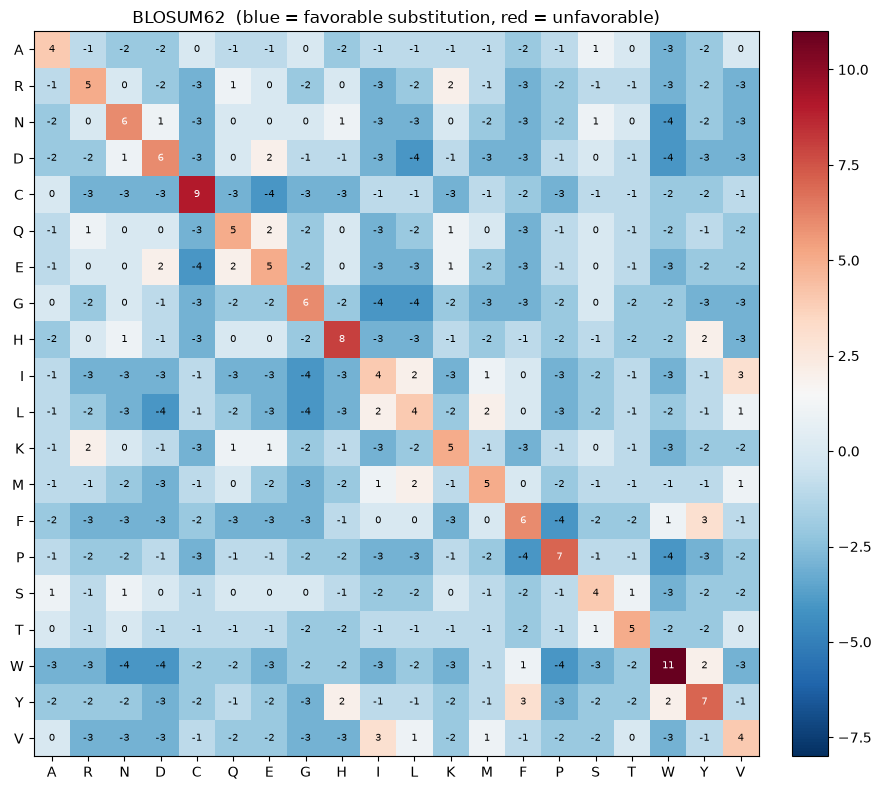

In [7]:
# Draw a protein scoring matrix as a heatmap, with the values written in.
import numpy as np
import matplotlib.pyplot as plt

def show_matrix(matrix, name="scoring matrix", letters="ARNDCQEGHILKMFPSTWYV"):
    """Display a substitution matrix (e.g. BLOSUM62) as an annotated heatmap."""
    n = len(letters)
    M = np.array([[matrix[(a, b)] for b in letters] for a in letters], dtype=float)
    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(M, cmap="RdBu_r", vmin=-8, vmax=11)
    ax.set_xticks(range(n)); ax.set_xticklabels(list(letters))
    ax.set_yticks(range(n)); ax.set_yticklabels(list(letters))
    for i in range(n):
        for j in range(n):
            ax.text(j, i, int(M[i, j]), ha="center", va="center",
                    color="white" if abs(M[i, j]) > 5 else "black", fontsize=7)
    ax.set_title(f"{name}  (blue = favorable substitution, red = unfavorable)")
    fig.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

# Show the default protein matrix so you can see what the app is using.
show_matrix(BLOSUM62, "BLOSUM62")


In [8]:
# The control panel. Drag a slider or edit a sequence and the alignment redraws.
import ipywidgets as widgets
from IPython.display import display, clear_output

seq1_box = widgets.Textarea(value="GTTTTGCTTGGAT", description="Seq 1:",
                            layout=widgets.Layout(width="95%", height="55px"))
seq2_box = widgets.Textarea(value="GTTTTGATATTAGTTGGAT", description="Seq 2:",
                            layout=widgets.Layout(width="95%", height="55px"))
match_sl    = widgets.FloatSlider(value=2, min=0, max=5,  step=0.5, description="match")
mismatch_sl = widgets.FloatSlider(value=2, min=0, max=5,  step=0.5, description="mismatch")
gap_sl      = widgets.FloatSlider(value=3, min=0, max=10, step=0.5, description="gap")
mode_dd   = widgets.Dropdown(options=["Global", "Local"], value="Global", description="mode")
type_dd   = widgets.Dropdown(options=["DNA", "Protein"],  value="DNA",    description="type")
matrix_dd = widgets.Dropdown(options=["BLOSUM62", "PAM250"], value="BLOSUM62", description="matrix")
out = widgets.Output()

def _recompute(*_):
    with out:
        clear_output(wait=True)
        s1 = "".join(seq1_box.value.split()).upper()
        s2 = "".join(seq2_box.value.split()).upper()
        if not s1 or not s2:
            print("Type a sequence into both boxes."); return
        if type_dd.value == "DNA":
            scorer = dna_scorer(match_sl.value, mismatch_sl.value)
        else:
            scorer = matrix_scorer(BLOSUM62 if matrix_dd.value == "BLOSUM62" else PAM250)
        gap = gap_sl.value
        if mode_dd.value == "Global":
            r1, r2, score = align_global(s1, s2, scorer, gap)
            where = ""
        else:
            r1, r2, score, a1, b1, a2, b2 = align_local(s1, s2, scorer, gap)
            where = f"   aligned region: seq1[{a1}:{b1}], seq2[{a2}:{b2}]"
        n_gaps, gap_lengths = gap_stats(r1, r2)
        display(render_alignment_html(r1, r2))
        print(f"score             = {score:g}{where}")
        print(f"percent identity  = {percent_identity(r1, r2):.1f}%")
        print(f"number of gaps    = {n_gaps}")
        print(f"gap lengths       = {gap_lengths}")

# matrix dropdown only matters for protein; gray it out for DNA
def _toggle_matrix(*_):
    matrix_dd.disabled = (type_dd.value == "DNA")
type_dd.observe(_toggle_matrix, names="value"); _toggle_matrix()

for w in (seq1_box, seq2_box, match_sl, mismatch_sl, gap_sl, mode_dd, type_dd, matrix_dd):
    w.observe(_recompute, names="value")

panel = widgets.VBox([seq1_box, seq2_box,
                      widgets.HBox([match_sl, mismatch_sl, gap_sl]),
                      widgets.HBox([mode_dd, type_dd, matrix_dd])])
display(panel, out)
_recompute()


Output()

## Part 4 - How the alignment is built (pictures)

Here are two pictures that show how the aligner works and what it sees.

The first is the scoring grid itself. One sequence runs down the side, the other across the top. Each box holds the best score for lining up everything up to that point. The red path is the route the aligner takes back through the grid, and that path is the alignment.

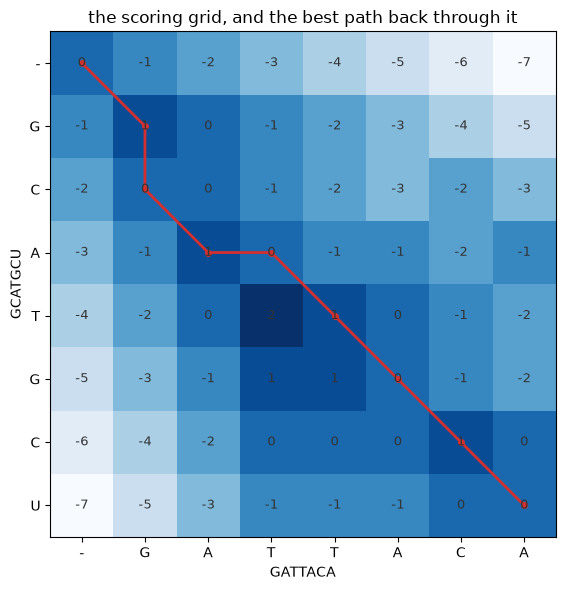

In [9]:
# The scoring grid and the best path through it, for a short example.
import numpy as np
import matplotlib.pyplot as plt

def dp_grid(s1, s2, match=1, mismatch=1, gap=1):
    n, m = len(s1), len(s2)
    S = [[0.0] * (m + 1) for _ in range(n + 1)]
    for i in range(1, n + 1):
        S[i][0] = -i * gap
    for j in range(1, m + 1):
        S[0][j] = -j * gap
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            diag = S[i - 1][j - 1] + (match if s1[i - 1] == s2[j - 1] else -mismatch)
            S[i][j] = max(diag, S[i - 1][j] - gap, S[i][j - 1] - gap)
    # walk back from the corner
    i, j = n, m
    path = [(i, j)]
    while i > 0 or j > 0:
        if i > 0 and j > 0 and S[i][j] == S[i - 1][j - 1] + (match if s1[i - 1] == s2[j - 1] else -mismatch):
            i, j = i - 1, j - 1
        elif i > 0 and S[i][j] == S[i - 1][j] - gap:
            i -= 1
        else:
            j -= 1
        path.append((i, j))
    return np.array(S), path

s1, s2 = "GCATGCU", "GATTACA"
S, path = dp_grid(s1, s2)
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.imshow(S, cmap="Blues")
for i in range(S.shape[0]):
    for j in range(S.shape[1]):
        ax.text(j, i, int(S[i, j]), ha="center", va="center", fontsize=9, color="#333")
ax.plot([p[1] for p in path], [p[0] for p in path], color="#d32f2f", linewidth=2, marker="o", markersize=4)
ax.set_xticks(range(len(s2) + 1)); ax.set_xticklabels(["-"] + list(s2))
ax.set_yticks(range(len(s1) + 1)); ax.set_yticklabels(["-"] + list(s1))
ax.set_xlabel(s2); ax.set_ylabel(s1)
ax.set_title("the scoring grid, and the best path back through it")
plt.tight_layout()
plt.show()

The second picture is a dot plot. It puts a dot everywhere the two sequences share a short piece. When two sequences are related, the dots line up into a diagonal. Breaks and jumps in the diagonal are exactly where insertions, deletions, and big differences are. Here are human and zebrafish hemoglobin beta.

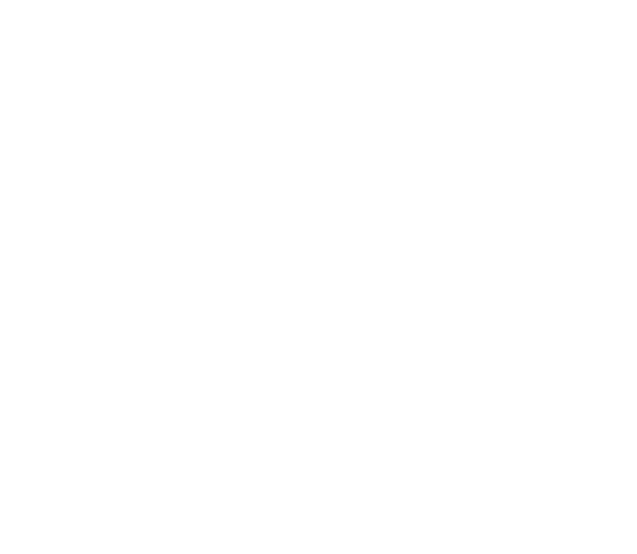

In [10]:
# Dot plot: a dot wherever a short window matches in both sequences.
import matplotlib.pyplot as plt

def dot_plot_points(a, b, k=3):
    seen = {}
    for j in range(len(b) - k + 1):
        seen.setdefault(b[j:j + k], []).append(j)
    xs, ys = [], []
    for i in range(len(a) - k + 1):
        for j in seen.get(a[i:i + k], []):
            xs.append(j); ys.append(i)
    return xs, ys

xs, ys = dot_plot_points(HBB_HUMAN, HBB_ZEBRAFISH, k=2)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(xs, ys, s=4, color="#2E7D46")
ax.set_xlabel("zebrafish HBB position")
ax.set_ylabel("human HBB position")
ax.set_title("dot plot (matching 2-letter windows). The diagonal is the shared protein.")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Part 5 - Good vs bad parameters: a toy example

## Good vs. bad parameters: a DNA toy example

Before we trust an aligner on real genes, we should check one thing. **The parameters matter as much as the algorithm.** The same two sequences can produce a sensible alignment or a nonsensical one depending only on how we set the match reward, mismatch penalty, and gap penalty.

We'll use a tiny made-up DNA pair so we know the *right* answer in advance:

```
seq1 = GTTTTG            CTTGGAT     (13 bp)
seq2 = GTTTTG  ATATTA   GTTGGAT     (19 bp)
```

This is how `seq2` arose from `seq1`:

1. The two sequences share a left part (`GTTTTG`) and a right part (`...TTGGAT`).
2. A **6-base block `ATATTA` was inserted** into `seq2` in the middle.
3. There is also **one point substitution**. The `C` at the start of the right part became a `G` (`CTTGGAT` becomes `GTTGGAT`).

So the biologically *intended* alignment is simple. One clean 6-base gap (the insertion) plus one single-letter mismatch. Everything else should line up. We'll see which parameters recover that, and which ones don't.

In [11]:
# Toy DNA pair. seq2 = seq1 with a 6-bp insertion (ATATTA) plus one C->G substitution.
# The biologically intended alignment is ONE 6-bp gap + ONE mismatch.
seq1 = "GTTTTGCTTGGAT"        # 13 bp:  GTTTTG | CTTGGAT
seq2 = "GTTTTGATATTAGTTGGAT"  # 19 bp:  GTTTTG | ATATTA (insert) | GTTGGAT


def show(label, row1, row2, score, scorer, gap):
    """Pretty-print one alignment with its score and readouts."""
    n_gaps, gap_lengths = gap_stats(row1, row2)
    print(label)
    print(format_alignment(row1, row2))
    print(f"  score             = {score:g}")
    print(f"  percent identity  = {percent_identity(row1, row2):.1f}%")
    print(f"  number of gaps    = {n_gaps}")
    print(f"  gap lengths       = {gap_lengths}")
    print()


# --- GOOD parameters -------------------------------------------------------
# match reward 2, mismatch penalty 2, and a gap penalty (3) big enough that
# opening a gap has to "earn its keep." This should give one clean 6-bp gap.
good_scorer = dna_scorer(match=2, mismatch=2)
g_row1, g_row2, g_score = align_global(seq1, seq2, good_scorer, gap=3)
show("GOOD params  (match=2, mismatch=2, gap=3):", g_row1, g_row2, g_score, good_scorer, 3)

# --- BAD parameters --------------------------------------------------------
# Same match/mismatch, but the gap penalty is almost free (0.1). Now gaps are
# so cheap the optimizer scatters them everywhere to harvest spurious matches.
bad_scorer = dna_scorer(match=2, mismatch=2)
b_row1, b_row2, b_score = align_global(seq1, seq2, bad_scorer, gap=0.1)
show("BAD params   (match=2, mismatch=2, gap=0.1):", b_row1, b_row2, b_score, bad_scorer, 0.1)

# Sanity check: re-derive each score from the printed rows. They should match.
print("alignment_score re-check (should equal the scores above):")
print(f"  GOOD: {alignment_score(g_row1, g_row2, good_scorer, 3):g}")
print(f"  BAD : {alignment_score(b_row1, b_row2, bad_scorer, 0.1):g}")

GOOD params  (match=2, mismatch=2, gap=3):
GTTTTG------CTTGGAT
||||||      .||||||
GTTTTGATATTAGTTGGAT

  score             = 4
  percent identity  = 92.3%
  number of gaps    = 1
  gap lengths       = [6]

BAD params   (match=2, mismatch=2, gap=0.1):
G---T--T-TT-GCTTGGAT
|   |  | || | ||||||
GTTTTGATATTAG-TTGGAT

  score             = 23.2
  percent identity  = 100.0%
  number of gaps    = 5
  gap lengths       = [3, 2, 1, 1, 1]

alignment_score re-check (should equal the scores above):
  GOOD: 4
  BAD : 23.2


### Why the "better" score is the worse answer

Look at what the optimizer actually returned:

| | GOOD (gap=3) | BAD (gap=0.1) |
|---|---|---|
| **score** | 4 | **23.2** (higher!) |
| **percent identity** | 92.3% | **100%** |
| **number of gaps** | **1** | 5 |
| **gap lengths** | [6] | [3, 2, 1, 1, 1] |

If you only looked at the numbers, the BAD alignment looks great. A higher score **and** 100% identity. But it is biological nonsense.

The GOOD alignment says one insertion event added six bases, and one base later mutated. That's two simple, common mutations, exactly how `seq2` was actually built.

The BAD alignment says there were **five separate insertion/deletion events** scattered all over a 19-base sequence (gaps of length 3, 2, 1, 1, 1). It reaches 100% identity by sliding letters around until every `A` happens to sit over an `A` and every `T` over a `T`, but those matches are coincidences, not shared ancestry. Five independent indels in such a short stretch is wildly improbable. The simpler one-insertion explanation is far more likely to be the truth.

The point is that the score is only as meaningful as the penalties you feed it. When gaps are almost free, the algorithm raises the score by shredding the alignment into many tiny gaps. The match/mismatch counts still look perfect, but the implied mutational history makes no sense. A gap penalty large enough to discourage pointless gaps (and a real mismatch penalty) is what keeps the *optimal* alignment and the *biologically sensible* alignment pointing at the same answer.

(Try it yourself. Nudge the gap penalty up from 0.1 toward 3 and watch the five scattered gaps collapse back into the single clean insertion.)

## Part 6 - Good vs bad parameters: a real gene (hemoglobin beta)

## Real genes: how "good" and "bad" parameters look on actual proteins

So far we tuned the aligner on toy sequences. Now we will see what good and bad parameter choices do to a real biological question.

We will line up hemoglobin-beta (HBB), the protein that carries oxygen in your blood, from human and zebrafish. These two are separated by hundreds of millions of years of evolution, so the proteins have drifted apart (only about half their amino acids still match) but they still do the same job. That makes them a good stress test. A good alignment should recover a sensible, mostly continuous correspondence, while a bad one will visibly fall apart.

Here is the trap we want to expose. It is tempting to judge an alignment by its raw score. Bigger score, better alignment, right? Watch what happens when we keep the same substitution matrix (BLOSUM62, the right tool for proteins) but set the gap penalty to zero. Gaps become free, so the aligner is free to sprinkle them everywhere to force extra letters to line up. The raw score goes up. The headline percent identity goes up too. And yet the alignment becomes biological nonsense.

You cannot trust the score (or even percent identity) on its own. You also have to look at the gap structure, meaning how many separate insert and delete events the alignment is claiming happened.

In [12]:
# Compare two parameter choices on the SAME distant pair:
# human vs zebrafish hemoglobin-beta (HBB) protein.
seq1, seq2 = HBB_HUMAN, HBB_ZEBRAFISH
blosum = matrix_scorer(BLOSUM62)   # BLOSUM62 is the right scorer for proteins

def report(label, row1, row2, score):
    """Print the headline metrics AND the gap structure for one alignment."""
    runs, lengths = gap_stats(row1, row2)
    print(label)
    print(f"  raw score         : {score:.0f}")
    print(f"  percent identity  : {percent_identity(row1, row2):.1f}%")
    print(f"  alignment length  : {len(row1)} columns")
    print(f"  gap runs          : {runs}   (= number of separate insert/delete events)")
    print(f"  total gap columns : {sum(lengths)}")
    print()

# GOOD: BLOSUM62 with a sensible gap penalty.
# A penalty of 10 means "only open a gap if the matrix evidence really justifies it."
good_row1, good_row2, good_score = align_global(seq1, seq2, blosum, gap=10)
report("GOOD  ->  BLOSUM62, gap = 10", good_row1, good_row2, good_score)

# BAD: SAME matrix, but gap penalty = 0, so gaps cost nothing.
# The aligner now scatters gaps everywhere to manufacture extra matches.
bad_row1, bad_row2, bad_score = align_global(seq1, seq2, blosum, gap=0)
report("BAD   ->  BLOSUM62, gap = 0", bad_row1, bad_row2, bad_score)

# Side by side: the score went UP while the biology fell apart.
print(f"Raw score : {good_score:.0f}  ->  {bad_score:.0f}   "
      f"(+{bad_score - good_score:.0f}, so the BAD one 'looks' better)")
print(f"Gap runs  : {gap_stats(good_row1, good_row2)[0]}    ->  {gap_stats(bad_row1, bad_row2)[0]}     "
      f"(the BAD one claims an absurd number of indel events)")

GOOD  ->  BLOSUM62, gap = 10
  raw score         : 419
  percent identity  : 51.7%
  alignment length  : 148 columns
  gap runs          : 1   (= number of separate insert/delete events)
  total gap columns : 1

BAD   ->  BLOSUM62, gap = 0
  raw score         : 497
  percent identity  : 71.6%
  alignment length  : 179 columns
  gap runs          : 29   (= number of separate insert/delete events)
  total gap columns : 63

Raw score : 419  ->  497   (+78, so the BAD one 'looks' better)
Gap runs  : 1    ->  29     (the BAD one claims an absurd number of indel events)


In [13]:
# Now SEE the difference. The GOOD alignment reads as a clean, near-continuous
# correspondence; the BAD one is shredded with gaps.
print("=" * 62)
print("GOOD alignment (BLOSUM62, gap=10) - first 60 columns")
print("=" * 62)
print(format_alignment(good_row1, good_row2, width=60).split("\n\n")[0])

print()
print("=" * 62)
print("BAD alignment (BLOSUM62, gap=0) - first 60 columns")
print("=" * 62)
print(format_alignment(bad_row1, bad_row2, width=60).split("\n\n")[0])

# Tip: the '-' characters are gaps. Count how many little gap clusters appear
# in each block. The GOOD block flows; the BAD block is riddled with dashes.

GOOD alignment (BLOSUM62, gap=10) - first 60 columns
MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPK
||..|..|..|...||||.|.||.|..||.|.|.|||||||.|..||.||.|.|.|||||
MVEWTDAERTAILGLWGKLNIDEIGPQALSRCLIVYPWTQRYFATFGNLSSPAAIMGNPK

BAD alignment (BLOSUM62, gap=0) - first 60 columns
MV--HLTPE-EKSAVTA---LWGKVNVDEVG-GEALGR-LLVVYPWTQRFF-ESFGDLST
||    | . |.   ||   ||||.|.||.|  .||.|  |.|||||||.|  .||.||.
MVEW--T-DAER---TAILGLWGKLNIDEIGP-QALSRC-LIVYPWTQRYFA-TFGNLSS


### Reading the result: why the "better" score is the worse biology

Look at what just happened to the numbers:

| | GOOD (gap = 10) | BAD (gap = 0) |
|---|---|---|
| raw score | 419 | **497** (higher) |
| percent identity | 51.7% | **71.6%** (higher) |
| alignment length | 148 columns | 179 columns |
| gap runs (indel events) | **1** | 29 |
| total gap columns | **1** | 63 |

The BAD parameters win on both headline numbers, a higher score and a higher percent identity. If you only printed those two numbers, you would pick the wrong alignment. This is exactly why you cannot stop at the score.

What actually went wrong: with a free gap penalty, the aligner inserted 63 gap characters across 29 separate gap runs into two proteins that are each only about 147 residues long. Every time it did not like a mismatch, it just slid one sequence over by inserting a gap until a matching letter happened to line up. That is how the percent identity got artificially pumped from 52% to 72%. Those extra matches are manufactured by gaps, not by real shared ancestry.

Biologically, 29 independent insertion and deletion events between human and zebrafish hemoglobin is unreasonable. Real protein evolution is stingy with indels. They shift the reading of everything downstream and usually break the protein, so they are rare and they happen in a few discrete spots, not 29 of them. The GOOD alignment captures this with a single, tiny gap, and its roughly 52% identity is the honest, biologically reasonable level of conservation for two animals this distantly related.

The takeaway for tuning your own aligner: the raw score is just the number your scoring rules are built to maximize. Make gaps free and of course the score climbs. To judge whether an alignment is biologically meaningful, look past the score to the gap structure (few, well-placed gaps versus many scattered ones) and check the percent identity against what you would expect for how related the two species are. A good gap penalty is the knob that keeps the aligner honest.

## Part 7 - DNA vs protein: the SARS spike

## DNA vs protein: which mutations actually matter?

This is the main part of the project. We have the **spike gene** from two coronaviruses:

- **SARS-CoV** (the 2003 SARS virus)
- **SARS-CoV-2** (the virus behind COVID-19)

The spike protein is the part on the virus surface that grabs onto human cells, so changes here are interesting. We align these two spike sequences twice. First as raw **DNA**, then as the **protein** they code for. Then we ask one question:

> When the DNA differs but the protein stays the same, what does that tell us about which mutations are important?

DNA is read three letters (a codon) at a time, and each codon specifies one amino acid. The genetic code is redundant. Several codons can spell the same amino acid (for example, `TTC` and `TTT` both mean phenylalanine, `F`). So a DNA change does not always change the protein.

We sort every aligned codon column into three groups:

| Group | DNA | Protein | Meaning |
|---|---|---|---|
| **Identical** | same codon | same amino acid | no change at all |
| **Synonymous** | codon changed | amino acid unchanged | a silent mutation |
| **Nonsynonymous** | codon changed | amino acid changed | a mutation that can change function |

The DNA and protein alignments disagree exactly at the synonymous sites, and that is what we want to look at.

In [14]:
# DNA vs. protein comparison of the two spike sequences.
# All engine functions and the SARS_COV*_SPIKE_* sequences are already defined above.

# --- 1. Align the spike genes as DNA -------------------------------------
# dna_scorer(match, mismatch): +1 for a matching base, -1 for a mismatch.
# gap=2 means each gap position subtracts 2. (match/match-value are rewards
# that get ADDED; mismatch and gap are penalty magnitudes that get SUBTRACTED.)
dna_row1, dna_row2, dna_score = align_global(
    SARS_COV_SPIKE_DNA, SARS_COV2_SPIKE_DNA,
    dna_scorer(1, 1), gap=2,
)
dna_len  = len(dna_row1)
dna_pid  = percent_identity(dna_row1, dna_row2)
dna_gaps, _ = gap_stats(dna_row1, dna_row2)

# --- 2. Align the spike proteins with BLOSUM62 ---------------------------
# BLOSUM62 scores amino-acid pairs by how often evolution swaps them.
# gap=10 is a sensible protein gap penalty for this matrix.
prot_row1, prot_row2, prot_score = align_global(
    SARS_COV_SPIKE_PROT, SARS_COV2_SPIKE_PROT,
    matrix_scorer(BLOSUM62), gap=10,
)
prot_len  = len(prot_row1)
prot_pid  = percent_identity(prot_row1, prot_row2)
prot_gaps, _ = gap_stats(prot_row1, prot_row2)

# --- 3. Walk the PROTEIN alignment and classify each codon column --------
# We keep a separate codon index (i, j) into each gene. Every time a side
# has a real residue (not a gap), we look up its codon and then advance
# that side's index by one. Columns where either side is a gap are skipped.
def codon_at(dna, residue_index):
    """Return the 3-letter codon coding for residue `residue_index` (0-based)."""
    start = residue_index * 3
    return dna[start:start + 3]

i = j = 0                      # codon index into SARS-CoV / SARS-CoV-2 genes
identical = synonymous = nonsynonymous = 0
syn_examples = []              # collect a few concrete synonymous changes

for a, b in zip(prot_row1, prot_row2):
    if a != '-' and b != '-':          # both sides have a real residue
        codon_a = codon_at(SARS_COV_SPIKE_DNA,  i)
        codon_b = codon_at(SARS_COV2_SPIKE_DNA, j)
        if a == b:                     # same amino acid
            if codon_a == codon_b:
                identical += 1
            else:                      # codon changed but amino acid did not
                synonymous += 1
                if len(syn_examples) < 6:
                    # residue number = 1-based position in the SARS-CoV protein
                    syn_examples.append((i + 1, codon_a, codon_b, a))
        else:                          # amino acid changed
            nonsynonymous += 1
    # advance each side's codon index only when that side had a residue
    if a != '-':
        i += 1
    if b != '-':
        j += 1

# --- Tidy summary --------------------------------------------------------
print("SPIKE: SARS-CoV vs SARS-CoV-2")
print("=" * 52)
print("DNA alignment   (dna_scorer 1/1, gap 2)")
print(f"  length            : {dna_len}")
print(f"  score             : {dna_score:.0f}")
print(f"  percent identity  : {dna_pid:.2f}%")
print(f"  gap columns       : {dna_gaps}")
print()
print("Protein alignment (BLOSUM62, gap 10)")
print(f"  length            : {prot_len}")
print(f"  score             : {prot_score:.0f}")
print(f"  percent identity  : {prot_pid:.2f}%")
print(f"  gap columns       : {prot_gaps}")
print()
total_cols = identical + synonymous + nonsynonymous
print(f"Codon columns classified (both sides non-gap): {total_cols}")
print(f"  identical codon       : {identical}")
print(f"  synonymous (silent)   : {synonymous}")
print(f"  nonsynonymous (change): {nonsynonymous}")
print()
print("A few synonymous changes (DNA differs, protein identical):")
print(f"  {'residue':>7}  {'SARS':>4}  {'SARS2':>5}  amino acid")
for res_num, c_old, c_new, aa in syn_examples:
    print(f"  {res_num:>7}  {c_old:>4}  {c_new:>5}      {aa}")

SPIKE: SARS-CoV vs SARS-CoV-2
DNA alignment   (dna_scorer 1/1, gap 2)
  length            : 3860
  score             : 1767
  percent identity  : 77.27%
  gap columns       : 95

Protein alignment (BLOSUM62, gap 10)
  length            : 1277
  score             : 5090
  percent identity  : 78.02%
  gap columns       : 17

Codon columns classified (both sides non-gap): 1251
  identical codon       : 538
  synonymous (silent)   : 438
  nonsynonymous (change): 275

A few synonymous changes (DNA differs, protein identical):
  residue  SARS  SARS2  amino acid
        4   TTC    TTT      F
        5   TTA    CTT      L
        8   CTT    TTG      L
       10   CTC    CTA      L
       12   AGT    TCT      S
       20   ACC    ACA      T


### What the numbers mean

The DNA and protein alignments land at almost the same percent identity, about **77%** for DNA and **78%** for protein. At first that looks boring, like the answer is the same either way. But the codon classification shows what is hiding under that single number.

Of the roughly **1,250** codon columns where both viruses have a residue:

- **~538 are identical**. Same codon, same amino acid. Nothing happened.
- **~438 are synonymous**. The DNA changed but the protein did not. These are the columns where the two alignments disagree. The DNA alignment marks them as a difference, the protein alignment marks them as a match.
- **~275 are nonsynonymous**. The amino acid actually changed.

So where do DNA and protein disagree? At the synonymous sites. The protein alignment does not see about 438 real DNA differences, because the redundancy of the genetic code absorbs them. Look at the example changes. Many are in the third base of the codon (`TTC` to `TTT`, `ACC` to `ACA`, `CTC` to `CTA`). The third position is the "wobble" position, the least constrained base, so a change there often leaves the amino acid the same.

### Why this matters

This is the difference between a mutation that exists and a mutation that matters:

- **Synonymous (silent) mutations** change the DNA letter but produce the same protein. The cell builds an identical spike. These pile up freely over time, which is why DNA collects changes faster than protein.
- **Nonsynonymous mutations** change an amino acid, which can reshape the spike, change how tightly it grabs a cell, or help the virus dodge antibodies. These are the ones natural selection acts on, and the ones that can actually change function.

The point for a sequence aligner: the alphabet you choose decides what you can detect. Aligning DNA shows every letter-level change, including hundreds of silent ones. Aligning protein filters those out and shows only changes that reach the amino-acid level, which are the changes most likely to affect biology. Neither one is more correct. They answer different questions. To count all mutations, use DNA. To find the mutations that might change how the virus works, use protein.

### Two more pictures of the same story

The bar chart sorts every codon column into identical, synonymous, or nonsynonymous. The line plot slides a window along the spike and measures percent identity as it goes, so you can see which parts of the protein stayed the same and which parts changed. The shaded band is the receptor-binding domain, the part that grabs human cells.

In [15]:
# Left: how the codon columns split up. Right: identity along the spike.
import matplotlib.pyplot as plt

pr1, pr2, _ = align_global(SARS_COV_SPIKE_PROT, SARS_COV2_SPIKE_PROT, matrix_scorer(BLOSUM62), 10)

# codon classification
i1 = i2 = 0
identical = synonymous = nonsyn = 0
for a, b in zip(pr1, pr2):
    if a == "-" or b == "-":
        if a != "-": i1 += 1
        if b != "-": i2 += 1
        continue
    c1 = SARS_COV_SPIKE_DNA[i1 * 3:i1 * 3 + 3]
    c2 = SARS_COV2_SPIKE_DNA[i2 * 3:i2 * 3 + 3]
    if c1 == c2: identical += 1
    elif a == b: synonymous += 1
    else: nonsyn += 1
    i1 += 1; i2 += 1

# sliding-window identity along the alignment (in SARS-CoV-2 residue numbers)
cols = list(zip(pr1, pr2))
win = 30
pos, ident = [], []
resi = 0
resi_at_col = []
for a, b in cols:
    if b != "-":
        resi += 1
    resi_at_col.append(resi)
for start in range(0, len(cols) - win + 1, 4):
    block = cols[start:start + win]
    both = [(a, b) for a, b in block if a != "-" and b != "-"]
    if both:
        pos.append(resi_at_col[start])
        ident.append(100 * sum(1 for a, b in both if a == b) / len(both))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].bar(["identical", "synonymous", "nonsynonymous"], [identical, synonymous, nonsyn],
            color=["#9ec7e8", "#bfe3c0", "#ef9a9a"], edgecolor="white")
for i, v in enumerate([identical, synonymous, nonsyn]):
    axes[0].text(i, v + 5, str(v), ha="center")
axes[0].set_ylabel("codon columns")
axes[0].set_title("where the DNA changes hide")

axes[1].axvspan(319, 541, color="#ffe0b2", alpha=0.6, label="receptor-binding domain")
axes[1].plot(pos, ident, color="#2E7D46", linewidth=1.2)
axes[1].set_xlabel("position along the spike (amino acid number)")
axes[1].set_ylabel("percent identity (window of 30)")
axes[1].set_title("which parts of the spike stayed the same")
axes[1].legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## Part 8 - What makes an alignment good? (the central question)

## The central quality question: how do you actually judge an alignment?

Everything we have built so far hands back a **score**. Bigger score, better alignment, right? Not so fast. Notice what we did to *get* that score. We picked a match reward, a mismatch penalty, and a gap penalty, and the engine subtracted and added our own numbers. The score is a measurement made with a ruler we ourselves drew. So the honest question for this whole project is:

> *Given that the score itself changes with your parameters, how would you quantify the quality of an alignment?*

This cell is the written answer. The next cell shows the key claim with real numbers from our own engine.

### Why the raw score is *not* a quality measure

The raw score is defined by your own choices. If you double the match reward, every alignment in the universe scores higher without a single column becoming more biologically correct. Watch this on a tiny DNA pair where we hold the sequences, the mismatch penalty, and the gap penalty fixed and only turn up the match reward:

| match reward | raw score | percent identity |
|---|---|---|
| 1 | **12** | 92.9% |
| 2 | **25** | 92.9% |
| 5 | **64** | 92.9% |

The score nearly multiplies by five (12 to 64). The alignment is the same string every time, so its biological quality has not changed at all. Percent identity, which does not depend on our reward, stays flat at 92.9%. The number got bigger. Nothing got better.

So a score is only meaningful inside one fixed parameter set. Comparing "score 777 for human vs gorilla" against "score 419 for human vs zebrafish" is fair only because we ran both under BLOSUM62 with gap=10. The instant the parameters differ, the scores are not on the same ruler and the comparison means nothing. Score is a tool the algorithm uses to *find* an alignment. It is not a verdict on whether that alignment is *true*.

### What *does* indicate quality

Real quality lives in measures that don't move just because we changed our scoring knobs, and in whether the alignment tells a believable biological story.

**(a) Percent identity.** This is the fraction of aligned, non-gap columns that match exactly. It is **parameter-independent** (it doesn't care what reward we chose), which is exactly why it is more trustworthy than score. In our own runs it cleanly separates close from distant homologs. Human vs gorilla hemoglobin-beta comes out at **99.3%** identity, human vs zebrafish at **51.7%**. That ordering matches biology (a great ape is far closer to us than a fish) and it does so without any appeal to our scoring choices. But identity has limits. It ignores *how long* the sequences are (5/5 identical residues is not the same evidence as 500/500), and it can be **gamed by gaps**, which leads straight to the next point.

**(b) Gap structure.** Two alignments with similar identity can imply wildly different evolutionary histories. Compare human vs zebrafish under two gap penalties from our engine:

| gap penalty | percent identity | gap structure |
|---|---|---|
| 10 (or affine 11/1) | 51.7% | **1 clean gap**, length 1 |
| 1 (cheap gaps) | **57.9%** | **9 scattered gaps** (lengths 1,1,4,2,2,1,1,1,2) |

The cheap-gap version reports *higher* identity (57.9% vs 51.7%), and it is the *worse* alignment. It bought those extra matches by sprinkling nine separate insertions and deletions across the protein. Biologically, nine independent indels is a far less believable history than one. A few long, well-placed indels (a whole loop inserted once) beat a confetti of tiny gaps every time. This is exactly why affine gaps (open plus extend) exist and why our gap=10 and affine 11/1 runs land on the same single clean gap. **Good gaps are rare and chunky, not many and scattered.**

**(c) Do the known functional regions line up?** The strongest sanity check is biological. If the alignment is real, the parts we *already know* are conserved should fall on top of each other. Hemoglobin-beta has two histidines that grip the heme iron (the proximal His and distal His). A trustworthy human/fish alignment must place those histidines in the same columns even across about 50% overall identity. Likewise, a SARS-CoV vs SARS-CoV-2 spike alignment should align the conserved structural motifs of the protein, not smear them. An alignment that scores well but misaligns the functional core is wrong no matter what the number says.

**(d) Statistical significance: is this better than chance?** A score of 419 means nothing until you ask what score you would get aligning *random* sequences of the same length and composition. This is the idea behind the **E-value / Z-score**: normalize the score against the distribution you'd expect by chance (roughly, how many standard deviations above the random mean, or how many such hits you'd expect in a database by luck). A useful homegrown version is **score-per-aligned-column**, which at least cancels out the length effect. The question is never "is the score big?" but "is the score big *for sequences this length*, compared to noise?"

**(e) Agreement with independent evidence.** The alignment is a hypothesis. Quality is how well it survives contact with evidence we did *not* feed it: known 3D structure, established homology, or what a professional tool (BLAST, Clustal) produces. If our human/gorilla result (99.3%) agrees with the textbook fact that these proteins are nearly identical, that agreement is real evidence of quality. The score is not.

**(f) Biological plausibility of the implied history.** Every alignment is a claim about mutations, insertions, and deletions that actually happened. Ask whether that story is reasonable. A single 4-residue loop insertion is plausible. Nine independent one-residue indels to scrape up a few matches is not.

### Bottom line

**A good alignment is one whose implied evolutionary history is biologically believable and stays stable across reasonable parameter choices, not the one with the biggest number.** The score is how the algorithm *searches*. Quality is judged by parameter-independent and biology-grounded checks: percent identity (read with its length and gap caveats), clean gap structure, correct registration of known functional sites, significance versus chance, and agreement with independent evidence. When the same alignment keeps showing up as you wiggle the match reward, the mismatch penalty, and the gap cost, *that stability* is the real signal. A number that only got bigger because you rewarded matches more generously is not.

In [16]:
# One concrete proof that raw score is not quality.
# We hold the sequences, mismatch penalty, and gap penalty FIXED and only
# turn up the match reward. Watch the score balloon while percent identity --
# which does not depend on our scoring choices -- does not budge.
#
# Uses ONLY the already-defined engine helpers: dna_scorer, align_global,
# percent_identity. (a and b differ at exactly one position.)

a = "GATTACAGATTACA"
b = "GATTACAGGTTACA"   # single substitution vs. a (position 9: A vs G)

print(f"{'match reward':>12} | {'raw score':>9} | {'percent identity':>16}")
print("-" * 45)
for match_reward in (1, 2, 5):
    scorer = dna_scorer(match_reward, 1)          # mismatch penalty fixed at 1
    row1, row2, score = align_global(a, b, scorer, 2)   # gap penalty fixed at 2
    pid = percent_identity(row1, row2)
    print(f"{match_reward:>12} | {score:>9.0f} | {pid:>15.1f}%")

# Takeaway: score roughly 5x's (12 -> 64) but the alignment is identical every
# time, so percent identity is pinned at 92.9%. The bigger number is NOT a
# better alignment -- it is just a more generous ruler.

match reward | raw score | percent identity
---------------------------------------------
           1 |        12 |            92.9%
           2 |        25 |            92.9%
           5 |        64 |            92.9%


## Part 9 (stretch) - The gap problem

## Stretch goal: the gap problem (why one gap penalty isn't enough)

So far every gap symbol has cost the same flat amount. That single number is doing two jobs at once, and they pull in opposite directions:

1. **Allow one long, real indel.** Real mutations routinely insert or delete a *block* of bases in a single event. A good alignment should be willing to open one long gap to line the rest of the sequences back up.
2. **Discourage many scattered short gaps.** When two bases simply *differ*, the honest call is a **mismatch**. A lazy aligner can cheat by sprinkling tiny gaps instead, which hides real differences and inflates the apparent identity.

With a **linear** penalty a gap of length *L* always costs exactly `L x gap`. So a 9-base block indel is charged the same *per base* as nine unrelated single-base gaps. The model literally cannot tell *"one 9-base event"* apart from *"nine separate 1-base events"* because they cost the same. That means:

- a **low** gap value (cheap gaps) lets the long indel through, but it *also* lets scattered differences fragment into little gaps, and
- a **high** gap value (expensive gaps) suppresses the scatter, but it *also* makes the one legitimate long indel painfully expensive.

There is no single linear value that says *"one long gap = fine, many short gaps = bad."* Now we build a concrete example and watch this happen.

### A toy pair with one real insertion plus scattered point changes

We build a small "ancestor" sequence and a "descendant" that differs from it in two biologically distinct ways:

- **one genuine 9-base insertion** in the middle (`CCCCCAAAA`), extra bases the ancestor never had, so the descendant is 9 bp longer; and
- **six scattered single-base substitutions** in the flanking regions, positions that simply *changed*, not inserted or deleted.

The "correct" alignment is therefore obvious to a human. **One 9-long gap** for the insertion, and the flanks lined up with a handful of **mismatches**. The question is whether a single linear gap penalty can recover that.

In [17]:
# Build the toy pair. Everything here is deterministic -- no randomness --
# so a fresh Run-All always reproduces the exact same sequences and numbers.

flank_left  = "ACGTACGTAACCGGTTACGTACGTACGT"   # 28 bp shared "before" region
flank_right = "TTGGCCAATTACGTACGTGGCCATTAACG"  # 29 bp shared "after" region
insertion   = "CCCCCAAAA"                       # 9 bp that ONLY the descendant has

ancestor   = flank_left + flank_right                 # no insertion
descendant = flank_left + insertion + flank_right      # carries the insertion

# Now sprinkle a few single-base SUBSTITUTIONS into the descendant's flanks.
# These are point changes, NOT indels -- the honest alignment calls them mismatches.
_next_base = {"A": "C", "C": "G", "G": "T", "T": "A"}
_d = list(descendant)
for pos in [4, 13, 22,
            len(flank_left) + len(insertion) + 5,
            len(flank_left) + len(insertion) + 15,
            len(flank_left) + len(insertion) + 24]:
    _d[pos] = _next_base[_d[pos]]
descendant = "".join(_d)

print("ancestor   (%d bp): %s" % (len(ancestor),   ancestor))
print("descendant (%d bp): %s" % (len(descendant), descendant))
print("length difference  = %d bp  <- this is the one real insertion"
      % (len(descendant) - len(ancestor)))

# One scorer reused throughout: reward matches +2, penalize mismatches by 3.
dna = dna_scorer(match=2, mismatch=3)

ancestor   (57 bp): ACGTACGTAACCGGTTACGTACGTACGTTTGGCCAATTACGTACGTGGCCATTAACG
descendant (66 bp): ACGTCCGTAACCGTTTACGTACTTACGTCCCCCAAAATTGGCGAATTACGTAGGTGGCCATAAACG
length difference  = 9 bp  <- this is the one real insertion


### Watching a single linear penalty fail

We align the same pair three times, changing **only** the gap penalty, and print the alignment plus `gap_stats` (how many *separate* gaps, and how long each one is) and percent identity. Watch the gap count swing as we turn the one knob we have.

In [18]:
def report(label, row1, row2, score):
    """Pretty-print one alignment with its gap profile and identity."""
    count, lengths = gap_stats(row1, row2)
    pid = percent_identity(row1, row2)
    print("----- %s -----" % label)
    print("score = %g | separate gaps = %d | gap lengths = %s | identity = %.1f%%"
          % (score, count, lengths, pid))
    print(format_alignment(row1, row2))

# Same pair, same scorer, ONLY the gap penalty changes.
for gap in (1, 2, 4):
    row1, row2, score = align_global(ancestor, descendant, dna, gap)
    report("linear, gap = %d" % gap, row1, row2, score)

----- linear, gap = 1 -----
score = 81 | separate gaps = 7 | gap lengths = [2, 2, 2, 9, 2, 2, 2] | identity = 100.0%
ACGT-ACGTAACCG-GTTACGTAC-GTACGT---------TTGGC-CAATTACGTA-CGT
||||  ||||||||  ||||||||  |||||         |||||  |||||||||  ||
ACGTC-CGTAACCGT-TTACGTACT-TACGTCCCCCAAAATTGGCG-AATTACGTAG-GT

GGCCAT-TAACG
||||||  ||||
GGCCATA-AACG

----- linear, gap = 2 -----
score = 66 | separate gaps = 1 | gap lengths = [9] | identity = 89.5%
ACGTACGTAACCGGTTACGTACGTACGT---------TTGGCCAATTACGTACGTGGCCA
||||.||||||||.||||||||.|||||         |||||.|||||||||.|||||||
ACGTCCGTAACCGTTTACGTACTTACGTCCCCCAAAATTGGCGAATTACGTAGGTGGCCA

TTAACG
|.||||
TAAACG

----- linear, gap = 4 -----
score = 48 | separate gaps = 1 | gap lengths = [9] | identity = 89.5%
ACGTACGTAACCGGTTACGTACGTACGT---------TTGGCCAATTACGTACGTGGCCA
||||.||||||||.||||||||.|||||         |||||.|||||||||.|||||||
ACGTCCGTAACCGTTTACGTACTTACGTCCCCCAAAATTGGCGAATTACGTAGGTGGCCA

TTAACG
|.||||
TAAACG



Read the two extremes against each other:

- **`gap = 1` (cheap gaps):** the aligner *does* keep the real 9-base gap, but it also shreds every scattered substitution into its own little pair of gaps. The result is **7 separate gaps** with lengths `[2, 2, 2, 9, 2, 2, 2]`. Worse, identity reads a flattering **100%**. Every column is now either a match or a gap, so the genuine point mutations have been *hidden inside gaps* instead of honestly counted as mismatches. That 100% is a lie the cheap penalty told us.

- **`gap = 2` and `gap = 4` (expensive gaps):** the scatter is gone. **1 clean gap** of length 9, exactly the real insertion, and identity drops to an honest **89.5%** because the point changes now show up as mismatches (`.` in the match line). Good, except the price of that one legitimate 9-base event keeps climbing (`9 x gap`). The score falls from 66 to 48 as we raise the penalty, even though *nothing about the biology changed*. Push the gap penalty a little higher and the aligner would rather break the real indel into mismatches than pay for it.

That is the dilemma in one screen. The value low enough to welcome the long indel (`gap = 1`) is the same value that invites scatter, and the value high enough to kill scatter punishes the one event we actually wanted to keep. **One number can't serve both goals.**

### The crux: linear penalties can't even *see* the difference

Here is the structural reason, made airtight. Take two alignments of the same little strings that have **the same matches** and **the same total number of gap symbols (9)**. The only difference is *grouping*. One packs them into a single 9-long gap, the other spreads them into nine separate 1-long gaps. Under a linear penalty they score **identically**, because linear cost depends only on *how many* gap symbols there are, never on *how they're grouped*.

In [19]:
# Two alignments: same letters, same matches, same 9 gap symbols total.
# Left version = ONE 9-long gap.  Right version = NINE separate 1-long gaps.
one_gap_top = "MMMMM---------MMMMM"
one_gap_bot = "MMMMMxxxxxxxxxMMMMM"

many_gaps_top = "M-M-M-M-M-M-M-M-M-M"   # 10 M's with a single gap between each
many_gaps_bot = "MxMxMxMxMxMxMxMxMxM"

print("grouping check:")
print("  one big gap   ->", gap_stats(one_gap_top,  one_gap_bot))    # (1, [9])
print("  many tiny gaps ->", gap_stats(many_gaps_top, many_gaps_bot))  # (9, [1]*9)

# Score BOTH under a linear penalty, for two different gap values, using the
# engine's own scoring function. (The 'M'/'x' letters just stand in for
# matched / mismatched columns; only the gap grouping differs.)
for gap in (1, 2):
    s_one  = alignment_score(one_gap_top,  one_gap_bot,  dna, gap)
    s_many = alignment_score(many_gaps_top, many_gaps_bot, dna, gap)
    print("LINEAR gap = %d:  one 9-gap -> %g   nine 1-gaps -> %g   identical? %s"
          % (gap, s_one, s_many, s_one == s_many))

grouping check:
  one big gap   -> (1, [9])
  many tiny gaps -> (9, [1, 1, 1, 1, 1, 1, 1, 1, 1])
LINEAR gap = 1:  one 9-gap -> 11   nine 1-gaps -> 11   identical? True
LINEAR gap = 2:  one 9-gap -> 2   nine 1-gaps -> 2   identical? True


The two alignments get **the same score** at every gap value (11 and 11 at `gap=1`; 2 and 2 at `gap=2`). To a linear model, *"one tidy 9-base insertion"* and *"nine random single-base gaps"* are the same thing. It has no vocabulary for the idea of a **gap event**, so no amount of tuning the single penalty can teach it the difference. We need a penalty whose shape itself distinguishes them.

### The fix: affine gaps (pay to *open*, pay less to *extend*)

An **affine** penalty splits the cost in two:

- a one-time **gap-open** cost charged the moment a new gap begins, plus
- a smaller **gap-extend** cost for each additional base in that *same* gap.

A gap of length *L* now costs `gap_open + (L - 1) x gap_extend`. Set `gap_open` much larger than `gap_extend` and the incentives finally line up:

- **one long gap** pays the big open cost just **once**, then cheap extensions, so a single real indel is affordable; while
- **many short gaps** each pay the big open cost **again and again**, so scatter is truly expensive.

The same two alignments from above now score very differently. One 9-gap costs `8 + 8x1 = 16`, but nine 1-gaps cost `9x8 = 72`. Same 9 gap symbols, **56 points** apart. Now we align the real toy pair with affine gaps and compare it to the linear runs.

In [20]:
# Affine gaps: opening a gap is pricey (8), extending an existing one is cheap (1).
# gap_open >> gap_extend is exactly what makes "one long gap" beat "many short gaps".
row1, row2, score = align_global_affine(ancestor, descendant, dna,
                                        gap_open=8, gap_extend=1)
report("affine, open = 8, extend = 1", row1, row2, score)

# Show the cost asymmetry the affine model creates, by hand, for length-9 gaps:
open_cost, ext_cost = 8, 1
one_long   = open_cost + 8 * ext_cost      # one 9-base gap: open once, extend 8x
nine_short = 9 * open_cost                  # nine 1-base gaps: open 9 separate times
print("\naffine cost of 9 gap symbols as ONE gap   :", one_long)
print("affine cost of 9 gap symbols as NINE gaps:", nine_short)
print("the long indel is cheaper by:", nine_short - one_long, "points")

----- affine, open = 8, extend = 1 -----
score = 68 | separate gaps = 1 | gap lengths = [9] | identity = 89.5%
ACGTACGTAACCGGTTACGTACGTACGT---------TTGGCCAATTACGTACGTGGCCA
||||.||||||||.||||||||.|||||         |||||.|||||||||.|||||||
ACGTCCGTAACCGTTTACGTACTTACGTCCCCCAAAATTGGCGAATTACGTAGGTGGCCA

TTAACG
|.||||
TAAACG


affine cost of 9 gap symbols as ONE gap   : 16
affine cost of 9 gap symbols as NINE gaps: 72
the long indel is cheaper by: 56 points


With affine gaps the aligner lands on the alignment a biologist would draw by hand. **One clean 9-base gap** for the insertion (`gap_stats` reports `1` gap of length `[9]`), the flanks matched up, and the point changes honestly counted as mismatches. Identity is **89.5%**, not the inflated 100% the cheap linear penalty produced. This is also **not** a knife-edge tuned value. Because opening a second gap always costs a fresh `gap_open`, the result stays a single clean indel across a wide band of `gap_open` settings, instead of flipping between "all scatter" and "no indel" the way the linear penalty did.

### Why affine is the biologically right shape

The affine penalty isn't a hack. It mirrors how indels actually arise. A single mutational event (a polymerase slip, an unequal crossover) inserts or deletes a *whole stretch* of bases at once. The expensive part, biologically, is that an indel *happened at all*, the rare event the `gap_open` cost stands for. Once the stretch is open, making it one base longer or shorter is comparatively common and cheap, which is exactly the small `gap_extend` cost. So affine scoring says what biology says. **Starting a gap is a big deal; extending one already there is not.** That one change in the *shape* of the penalty, not just its size, is what a single linear number could never express.

## Part 10 (stretch) - Sanity check vs a professional tool

## Stretch: Sanity check against a professional tool (Biopython)

We built our aligner from scratch, so a fair question is: **does it actually compute the right answer?**

The best way to find out is to run a real, widely used bioinformatics library on the same problem with the same scoring rules and check that we get the same answer. We'll use **Biopython**'s `PairwiseAligner` for that.

This is the key idea about what "same answer" means. A global alignment is the solution to an optimization problem. Find the arrangement of the two sequences (with gaps allowed) that maximizes the total score. That **maximum score is a single, well-defined number**. If two correct programs use the same scoring rules, they must report the same optimal score. So the score is the thing we insist must match.

The *picture* of the alignment (which letters line up, where the gaps go) does **not** have to match exactly, and we'll explain why below.

**Our test case:** human vs. gorilla **hemoglobin-beta** protein (~147 amino acids each, very closely related). We score with **BLOSUM62**, **global** alignment, and a single **linear gap penalty of 10**. We set up Biopython with those same three choices.

In [21]:
# In Colab, run:  !pip install biopython
#
# Sanity check: align the SAME two sequences with the SAME scoring rules in
# (a) our engine and (b) Biopython, then compare the optimal score and the
# percent identity. If our DP is correct, the optimal SCORES must match.

from Bio.Align import PairwiseAligner, substitution_matrices

# --- The two sequences and the matched parameters -------------------------
# HBB_HUMAN and HBB_GORILLA are already defined in an earlier cell.
seq_a, seq_b = HBB_HUMAN, HBB_GORILLA
GAP = 10  # linear gap-penalty MAGNITUDE (one flat cost per gap symbol)

# --- (a) Our engine -------------------------------------------------------
# matrix_scorer + BLOSUM62 gives the same scoring our other protein cells use.
our_scorer = matrix_scorer(BLOSUM62)
row1, row2, our_score = align_global(seq_a, seq_b, our_scorer, gap=GAP)
our_pid = percent_identity(row1, row2)

# --- (b) Biopython --------------------------------------------------------
aligner = PairwiseAligner()
aligner.mode = "global"                                       # Needleman-Wunsch
aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
# Biopython expects penalties as NEGATIVE numbers. Setting open == extend makes
# its gap model LINEAR, matching our single flat 'gap' penalty above.
aligner.open_gap_score = -GAP
aligner.extend_gap_score = -GAP

bio_alignment = aligner.align(seq_a, seq_b)   # a lazy collection of all optima
bio_score = bio_alignment.score
best = bio_alignment[0]                        # one optimal alignment to inspect
bio_row1, bio_row2 = str(best[0]), str(best[1])
bio_pid = percent_identity(bio_row1, bio_row2)  # reuse OUR metric for fairness

# --- Side-by-side report --------------------------------------------------
print(f"{'':<12}{'optimal score':>15}{'% identity':>14}")
print(f"{'our engine':<12}{our_score:>15.1f}{our_pid:>13.2f}%")
print(f"{'Biopython':<12}{bio_score:>15.1f}{bio_pid:>13.2f}%")
print()
print("scores agree:", our_score == bio_score)
print("number of co-optimal alignments Biopython found:", len(bio_alignment))

              optimal score    % identity
our engine            777.0        99.32%
Biopython             777.0        99.32%

scores agree: True
number of co-optimal alignments Biopython found: 1


### What we got, and what it means

```
            optimal score    % identity
our engine          777.0        99.32%
Biopython           777.0        99.32%
```

**The optimal scores match exactly (777.0).** That's the result we cared about most. Our hand-written dynamic-programming code finds the same optimum as a mature, professionally maintained library, using the same scoring rules. The percent identities also match (99.32%). These two proteins differ at just **one** position (an R to K swap, Arg vs Lys, two chemically similar amino acids), so the alignment needs no gaps at all.

Because no gaps are needed here, this particular alignment is **unique**. Biopython reports exactly **1** optimal alignment, and its alignment strings come out identical to ours.

### Why two "correct" alignments can look different yet score the same

That won't always happen. Often there are **many** different arrangements that all hit the same maximum score. These are called **co-optimal alignments** (ties). For example, if a gap could sit one column to the left or one column to the right without changing the total score, both placements are equally optimal. The dynamic-programming math says these are tied, and each program then applies its own **tie-breaking rule** to pick one to display.

So when you compare two aligners:

- The **optimal score** is unique and *must* agree. It's the answer to a well-defined max problem. This is the real check that our engine is correct.
- The **alignment strings** (and therefore the displayed percent identity, since that's measured on the chosen layout) can differ when ties exist, simply because the two tools broke the tie differently. That's a cosmetic difference, **not** a disagreement about the optimum.

In short, agreeing on the score is the meaningful test, and our engine passes it. Differences in the exact picture, when they occur, are just two tools making different but equally valid choices among tied optima.

## Part 11 (stretch) - Seeing the mutations in 3D

We found that 297 amino acids changed between the 2003 SARS spike and the SARS-CoV-2 spike. Those are just numbers in a list. Here we put them on the real 3D shape of the spike protein, so you can see where the changes sit on the actual part the virus uses to enter human cells.

The first picture is a plain image, so it shows up everywhere (Colab, the exported HTML, or your own machine). The second one is interactive: in Google Colab you can grab it and rotate it. Red means the amino acid changed. Gray means it stayed the same. The red spots come straight from our own aligner, not from a database.

297 of 1273 spike residues changed


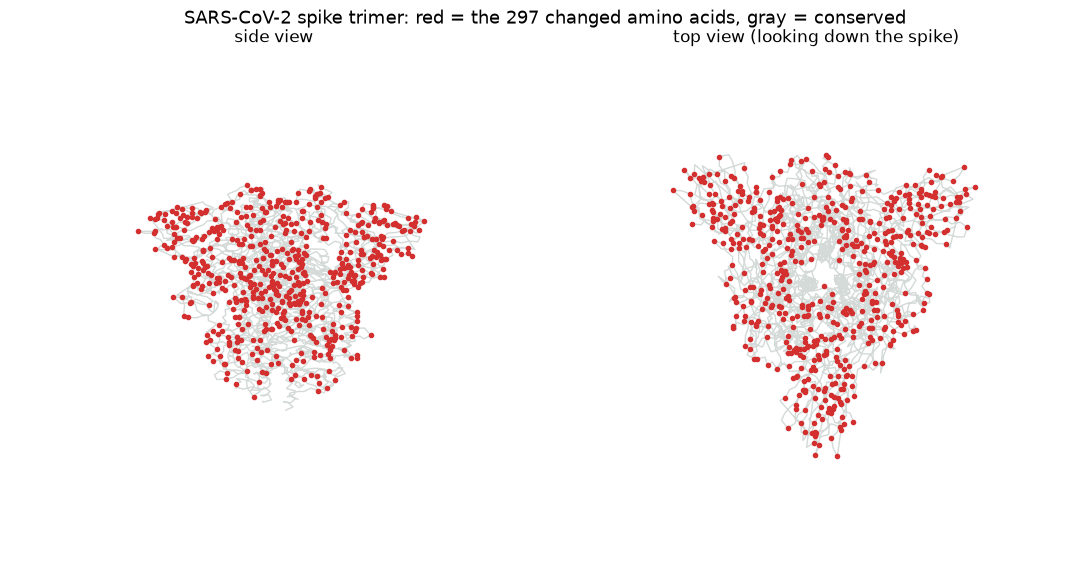

In [22]:
# Static 3D picture of the spike, colored by what changed. This renders as a
# normal image, so it always shows up (unlike the live viewer below).
import urllib.request
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# 1. Which residues changed, found with our own aligner.
pr1, pr2, _ = align_global(SARS_COV_SPIKE_PROT, SARS_COV2_SPIKE_PROT, matrix_scorer(BLOSUM62), 10)
changed = set()
resi2 = 0
for a, b in zip(pr1, pr2):
    if b == "-":
        continue
    resi2 += 1
    if a == "-" or a != b:
        changed.add(resi2)
print(len(changed), "of", len(SARS_COV2_SPIKE_PROT), "spike residues changed")

# 2. Download the real spike structure (PDB 6VXX) and read its backbone atoms.
url = "https://files.rcsb.org/download/6VXX.pdb"
pdb_text = urllib.request.urlopen(
    urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"}), timeout=30
).read().decode("utf-8", "ignore")

chains = {}
for line in pdb_text.splitlines():
    if line.startswith("ATOM") and line[12:16].strip() == "CA":
        chains.setdefault(line[21], []).append(
            (int(line[22:26]), float(line[30:38]), float(line[38:46]), float(line[46:54])))

# 3. Draw two angles of the trimer.
fig = plt.figure(figsize=(11, 6))
for k, (elev, azim, label) in enumerate([(15, 0, "side view"), (88, 0, "top view (looking down the spike)")]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    for atoms in chains.values():
        ax.plot([a[1] for a in atoms], [a[2] for a in atoms], [a[3] for a in atoms],
                color="#d3dad7", linewidth=1)
        red = [a for a in atoms if a[0] in changed]
        ax.scatter([a[1] for a in red], [a[2] for a in red], [a[3] for a in red],
                   color="#d32f2f", s=9, depthshade=False)
    ax.view_init(elev=elev, azim=azim)
    ax.set_axis_off()
    ax.set_title(label, fontsize=12)
fig.suptitle("SARS-CoV-2 spike trimer: red = the 297 changed amino acids, gray = conserved", fontsize=13)
plt.tight_layout()
plt.show()

In [23]:
# Interactive version: in Google Colab you can rotate this with the mouse.
try:
    import py3Dmol
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "py3Dmol"])
    import py3Dmol

view = py3Dmol.view(query="pdb:6VXX", width=760, height=520)
view.setStyle({"cartoon": {"color": "lightgray"}})              # conserved residues stay gray
view.addStyle({"resi": sorted(changed)}, {"cartoon": {"color": "red"}})  # changed residues turn red
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

What to look for:

- Most of the protein is gray. About three quarters of the spike is the same in both viruses, because it still has to fold and work.
- The red changes are not spread evenly. The head of the spike (the top, the part that grabs human cells and that antibodies aim at) is covered in red. The stalk that pushes the two membranes together is mostly gray.
- This is the same point as the DNA vs protein section, shown in 3D. The mutations that matter are the ones that change the amino acid, and they land where changing the protein actually changes how the virus behaves.

## Wrap-up

Every number in this notebook came from my own engine in Part 1. The big lesson: **changing the scoring changes the alignment**, so the raw score alone can't tell you which alignment is right - biology has to (percent identity, sensible gaps, conserved regions, and agreement with independent evidence).